# Stabilizing selection on a polygenic trait from the gene's eye-view

## Simulating the population

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.special as special
import scipy.stats as scp
import scipy.integrate as integ
import seaborn as sb
import statsmodels.api as sm
from tqdm import tqdm
import warnings
import unittest

from simulate_population import generate_pop

## Theoretical computations
Here, we give the functions necessary to compute theoretical predictions. These functions are used to generate Fig. 3-5 and in the appendix.

In [2]:
def gss(f, a0, b0, tolerance=1e-5):
    """
    Golden-section search
    to find the minimum of f on [a0,b0]
    * f: a strictly unimodal function on [a0,b0]

    Example:
     >>> def f(x): return (x - 2) ** 2
    >>> x = gss(f, 1, 5)
    >>> print(f"{x:.5f}")
    2.00000

    Credit to Wikipedia
    """
    a=a0
    b=b0
    invphi = (np.sqrt(5) - 1) / 2  # 1 / phi (inverse golden ratio)
    while b - a > tolerance:
        c = b - (b - a) * invphi
        d = a + (b - a) * invphi
        if f(c) < f(d):
            b = d
        else:  # f(c) > f(d) to find the maximum
            a = c
    if ((a-a0 < 2*tolerance) or (b0-b< 2*tolerance)):
        warnings.warn("The golden-section search found an answer close to the boundaries, maybe widen up the domain of the search")
    return (b + a) / 2

############################ Fixed point equation ##################################
# First we need to compute the integral of $x**{a-1} (1-x)**{b - 1} e**{cx + dx(1-x)}$
def integral_WF(a,b,c,d,klim):
    """
    Computes
    $sum_{k} c**k / (k!)   a(a+1)...(a+k-1)/((a+b)(a+b+1)...(a+b+2k-1)) 1F1(a+k,b;a+b+2k;c)$
    One can check that this is proportionnal to the integral of
    $x**{a-1} (1-x)**{b-1} e**{cx + dx(1-x)}$
    with proportionnality coefficient independent of c and d.
    klim is the precision of the approximation

    WARNING: this method fails if d>65 for klim=81
    """
    return np.sum([d**j/special.factorial(j) * special.poch(a,j) * special.poch(b,j)
                 /special.poch(a+b,2*j) * special.hyp1f1(a+j,a+b+2*j,c)
                for j in range(klim)],axis=0)

def mean_X(s,d,theta,klim=21):
    """
    Computes the mean of a WF diffusion with frequency-dependent (FD) selection
    xi(x) = s + d(1-2x)
    and mutation rates given by mu.

    Parameters
    ----------
    theta: tuple of two positive floats: mutation rates
    s: float: directional selection
    d: float: dominance coefficient
    klim: int: the precision of the approximation
    """
    return (theta[0]/(theta[0]+theta[1])
         *integral_WF(2*theta[0]+1,2*theta[1],2*s,2*d,klim)
         /integral_WF(2*theta[0],2*theta[1],2*s,2*d,klim))


def var_WF(s,d,theta,klim=21):
    """
    Computes E[X(1-X)] where X is a WF diffusion with frequency-dependent (FD) selection
    xi(x) = s + d(1-2x)
    and mutation rates given by theta.

    Parameters
    ----------
    theta: tuple of two positive floats: mutation rates
    s: float: directional selection
    d: float: dominance coefficient
    klim: int: the precision of the approximation (should be odd)
    """
    return np.max([np.min([theta[0]*theta[1]/((theta[0]+theta[1])*(theta[0]+theta[1]+1/2))
         *integral_WF(2*theta[0]+1,2*theta[1]+1,2*s,2*d,klim)
         /integral_WF(2*theta[0],2*theta[1],2*s,2*d,klim),
                         np.ones(np.shape(s))/4],axis=0),
                 np.zeros(np.shape(s))],axis=0)

def mean_phenotype(s,d,theta,L,list_alpha,list_proba_alpha,klim=21):
    """Finds the mean phenotype.
    Parameters:
    ----------
    theta: mutation rates (tuple of two positive floats)

    s: effective selection coefficient s*

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    """
    return L*np.sum(2*list_alpha*mean_X(s*list_alpha,
                                         d*list_alpha**2,
                                         theta,
                                         klim=klim)
                  *list_proba_alpha)

def genetic_variance_fp(s,omem2,theta,L,list_alpha,list_proba_alpha,klim=21):
    """Finds the mean E[2 alpha**2 X(1-X)].
    Arguments:
    ----------
    s: effective selection coefficient s*
    
    omem2: strength of selection ($= omega_e^{-2}$)

    theta: mutation rates (tuple of two positive floats)

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    """
    return L*np.sum(2*list_alpha**2*var_WF(s*list_alpha,
                                            -omem2*list_alpha**2/2,
                                            theta,
                                            klim=klim)
                  *list_proba_alpha)

def match_equation_fp(s,omem2,theta,eta,L,list_alpha,list_proba_alpha,klim=21):
    """Finds the absolute value of the distance between the mean phenotype and the
    optimum eta.
    
    Arguments:
    ----------
    s (float): effective selection coefficient s*

    omem2: strength of selection ($= omega_e^{-2}$)

    theta (tuple of 2 positive floats): mutation rates from 0 to +1 and back

    list_alpha (array of L positive floats): list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha (probability array of size L): the list of probabilities of each class in list_alpha
    """
    return np.abs(  (mean_phenotype(s,-omem2/2,theta,L,list_alpha,list_proba_alpha,klim)
                    -eta)   * omem2 + s)



def solve_fp(omem2,
                   theta,
                   eta,
                   L,
                   list_alpha,
                   list_proba_alpha,
                   tolerance=1e-5,
                   a0=-1000,
                   b0=1000,
                   klim=21):
    """Finds the value of s* given by the equation for strong selection for a WF diffusion with frequency-dependent 
    selection
    xi(x,alpha) = s* alpha +  N alpha**2/(2 om2)  (1-2x)

    Parameters:
    ----------
    omem2: inverse strength of selection (=omega_e^{-2})
    theta: mutation rates (the probability of mutation at one locus from 0 to +1 is
          theta[0] per organism per generation)
    eta: optimum
    N: population size (number of diploid organisms)
    L: number of loci
    list_alpha: list of values of additive effects
    list_proba_alpha: list of probabilities of the additive effects
    tolerance: precision
    a0,b0: domain in which the search is made
    """
    return gss(lambda s: match_equation_fp(s,
                                              omem2,
                                              theta,
                                              eta,
                                              L,
                                              list_alpha,
                                              list_proba_alpha,
                                              klim=klim),
             a0,b0, #Boundaries of the golden-section search
             tolerance=tolerance
    )


################# Genetic variance (small mutation rates) ####################
# If the mutation rate is small, then all computations for strong selection are the same as for moderate selection
# except for the genetic variance. We have
def mean_X1_X_sm(s,d,theta):
    """
    Computes the integral of e**(cx + dx(1-x))
    which is approximately equal to
    E[X(1-X)]
    if theta is small and X has distribution
    x**(theta[0]-1) * x**(theta[1]-1) * np.exp(s*x + d*x*(1-x))

    Parameters
    ----------
    s: array of float: directional selection coefficients to be evaluated
    d: float: dominance coefficients to be evaluated
    theta: tuple of two positive floats: mutation rates from 0 to +1 and back
    """
    return np.array([integ.quad(lambda x: np.exp(s[k]*x+d[k]*x*(1-x)),0,1)[0]
          /special.hyp1f1(2*theta[0],2*(theta[0]+theta[1]),s[k])
          * theta[0]*theta[1]/(theta[0]+theta[1]) #normalization constant
                   for k in range(np.shape(s)[0])
                  ])

def genetic_variance_fp_sm(s,omem2,theta,L,list_alpha,list_proba_alpha):
    """Finds the mean E[2 alpha**2 X(1-X)] under the assumption of small mutation rates.
    Arguments:
    ----------
    s: effective selection coefficient s*
    
    omem2: selection strength ($=omega_e^{-2}$)

    theta: mutation rates (tuple of two positive floats)

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    """
    return L*np.sum(2*list_alpha**2*mean_X1_X_sm(s*list_alpha,
                                               -omem2*list_alpha**2/2,
                                            theta)
                  *list_proba_alpha)

############################ Moderate selection ##################################
def mean_X_ms(s,theta):
    """Finds the mean X associated with a modified beta solution
    to a WF with selection s, mutation theta  under moderate selection.
    
    Parameters:
    -----------
    s: selection coefficient
    theta: tuple of two positive floats: mutation rates
    """
    return (theta[0]/(theta[0]+theta[1])
          *special.hyp1f1(2*theta[0]+1,2*(theta[0]+theta[1])+1,2*s)
          /special.hyp1f1(2*theta[0],2*(theta[0]+theta[1]),2*s))

def mean_sigma2_ms(s,theta):
    """Finds the mean X(1-X) associated with a modified beta solution
    to a WF with selection s, mutation theta
    
        Parameters:
    -----------
    s: selection coefficient
    theta: tuple of two positive floats: mutation rates
    """
    return (theta[0]*theta[1]/((theta[0]+theta[1])*(theta[0]+theta[1]+1/2))
          *special.hyp1f1(2*theta[0]+1,2*(theta[0]+theta[1])+2,2*s)
          /special.hyp1f1(2*theta[0],2*(theta[0]+theta[1]),2*s))

def mean_phenotype_ms(s,theta,L,list_alpha,list_proba_alpha):
    """Finds the mean phenotype.
    Arguments:
    ----------
    theta: mutation rates (tuple of two positive floats)

    s: effective selection coefficient s* (multiplied by 2N)

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    """
    return L*np.sum(2*list_alpha*mean_X_ms(s*list_alpha,theta)*list_proba_alpha)


def genetic_variance_ms(s,theta,L,list_alpha,list_proba_alpha):
    """Finds the mean LE[2alpha**2 X(1-X)] under moderate selection.
    
    Arguments:
    ----------
    s: effective selection coefficient s* (multiplied by 2N)

    theta: mutation rates (tuple of two positive floats)
    
    L: int>0: number of loci

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    """
    return L*np.sum(2*list_alpha**2*mean_sigma2_ms(s*list_alpha,theta)*list_proba_alpha)

def match_equation_ms(s,theta,eta,L,list_alpha,list_proba_alpha):
    """Finds the absolute value of the distance between the mean phenotype and the
    optimum eta  under moderate selection
    
    Arguments:
    ----------
    s: effective selection coefficient s* (multiplied by 2N)

    theta: mutation rates (tuple of two positive floats)

    eta: float in (0,2): selection optimum

    L: int>0: number of loci

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    """
    return np.abs(mean_phenotype_ms(s,theta,L,list_alpha,list_proba_alpha)-eta)

def solve_ms(theta,
                     eta,
                     L,
                     list_alpha,
                     list_proba_alpha,
                     tolerance=1e-5,
                     a0=-1000,
                     b0=1000):
    """Finds the value of s* given by the equation for moderate selection, searches
     on the interval (a0,b0)
     
         
    Arguments:
    ----------
    theta: mutation rates (tuple of two positive floats)

    eta: float in (0,2): selection optimum

    L: int>0: number of loci

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    
    tolerance: precision required on the golden-section search gss. Default 1e-5
    
    a0,b0: starting bounds on the golden-section search gss. Defalt -1000,1000
     """
    return gss(lambda s: match_equation_ms(s,
                                               theta,
                                               eta,
                                               L,
                                               list_alpha,
                                               list_proba_alpha),
             a0,b0, #Boundaries of the golden-section search
             tolerance=tolerance
  )

#######################Weak selection##############################
def match_equation_ws(s,omem2,theta,eta,L,list_alpha,list_proba_alpha):
    """Finds the absolute value of the distance between the mean phenotype and the
    optimum eta for weak selection
    
    Arguments:
    ----------
    s: effective selection coefficient s*
    
    omem2: selection strength ($=omega_e^{-2}$)

    theta (tuple of two positive floats): mutation rates

    eta (float in (0,2)): selection optimum
    
    L (int): number of loci

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    """
    return np.abs((mean_phenotype_ms(s,theta,L,list_alpha,list_proba_alpha)-eta)* omem2+s)

def solve_ws(omem2,
                     theta,
                     eta,
                     L,
                     list_alpha,
                     list_proba_alpha,
                     tolerance=1e-5,
                     a0=-1000,
                     b0=1000):
    """Finds the value of s* given by the equation for weak selection, searches
     on the interval (a0,b0).
     
        Arguments:
    ----------
    omem2: selection strength ($=omega_e^{-2}$)

    theta (tuple of two positive floats): mutation rates

    eta (float in (0,2)): selection optimum
    
    L (int): number of loci

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)

    list_proba_alpha: the list of probabilities of each class in list_alpha
    """
    return gss(lambda s: match_equation_ws(s,
                                               omem2,
                                               theta,
                                               eta,
                                               L,
                                               list_alpha,
                                               list_proba_alpha),
             a0,b0, #Boundaries of the golden-section search
             tolerance=tolerance
  )


## Observables: predictions vs simulations (Figure 2)
Here we plot Fig.3, comparing predictions and simulation results for macroscopic observables at stationarity.

In [3]:
#Parameters
theta= (.1,.2)
eta=1.2
L=100
list_alpha = np.load("alpha100.npy",allow_pickle=True)
list_proba_alpha = np.ones(L)/L

klim = 81 #Degree of precision for the theoretical computations under strong selection
#If klim is too low then the genetic variance sigma2_th_fp will have a bump for strong selection

In [4]:
burn_in = 1/2 #We consider that the system reaches stationarity after a fraction burn_in of the time
########## LOADING N=50 #########
N=50
nbpoints=20

omega = np.zeros(nbpoints)
list_means = np.zeros(nbpoints)
list_varmeans = np.zeros(nbpoints)
list_meanvarsX = np.zeros(nbpoints) #L E[alpha**2 X(1-X)]
list_varvarsX = np.zeros(nbpoints) #variance of the previous item
list_meanvars = np.zeros(nbpoints) #trait variance with linkage
list_varvars = np.zeros(nbpoints) #trait variance variance with linkage
list_rho = np.zeros(nbpoints) #Autocorrelation parameters

tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(0)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))

for k in range(nbpoints):
    tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(k)+".npy",allow_pickle=True)
    omega[k] = tmp[0]
    list_means[k] = eta-np.mean(tmp[3][-postburnin:])
    list_varmeans[k] = np.var(tmp[3][-postburnin:],ddof=1)
    list_rho[k] = -np.log(np.cov(tmp[3][-postburnin-1:-1],tmp[3][-postburnin:])[0,1]/list_varmeans[k])
    list_meanvarsX[k] = np.mean(tmp[4][-postburnin:])
    list_varvarsX[k] = np.var(tmp[4][-postburnin:],ddof=1)
    list_meanvars[k] = np.mean(tmp[5][-postburnin:])
    list_varvars[k] = np.var(tmp[5][-postburnin:],ddof=1)

omem2 = 2*N/omega**2 #Selection strength = $omega_e^{-2}$


In [5]:
########## LOADING N=500 #########
N2=500
nbpoints2=20

omega2 = np.zeros(nbpoints2)
list_means2 = np.zeros(nbpoints2)
list_varmeans2 = np.zeros(nbpoints2)
list_meanvarsX2 = np.zeros(nbpoints2) #L E[alpha**2 X(1-X)]
list_varvarsX2 = np.zeros(nbpoints2) #variance of the previous item
list_meanvars2 = np.zeros(nbpoints2) #trait variance with linkage
list_varvars2 = np.zeros(nbpoints2) #trait variance variance with linkage
list_rho2 = np.zeros(nbpoints2) #Autocorrelation parameters
list_rsq = np.zeros(nbpoints2) #r2 of log-autocorrelation

tmp = np.load("sims_L"+str(L)+"_N"+str(N2)+"/"+str(0)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))
for k in range(nbpoints2):
    tmp = np.load("sims_L"+str(L)+"_N"+str(N2)+"/"+str(k)+".npy",allow_pickle=True)
    omega2[k] = tmp[0]
    list_means2[k] = eta-np.mean(tmp[3][-postburnin:])
    list_varmeans2[k] = np.var(tmp[3][-postburnin:],ddof=1)
    list_rho2[k] = -np.log(np.cov(tmp[3][-postburnin-1:-1],tmp[3][-postburnin:])[0,1]/list_varmeans2[k])
    list_meanvarsX2[k] = np.mean(tmp[4][-postburnin:])
    list_varvarsX2[k] = np.var(tmp[4][-postburnin:],ddof=1)
    list_meanvars2[k] = np.mean(tmp[5][-postburnin:])
    list_varvars2[k] = np.var(tmp[5][-postburnin:],ddof=1)

tmp = None

omem22 = 2*N2/omega2**2 #This is the strength of selection omega_e^{-2}

In [6]:
#### Predictions ####
###Selection coefficients ###
#Moderate selection
sstar_ms = solve_ms(theta,eta,L,list_alpha,list_proba_alpha)

#Fixed point
sstar_fp = np.array([solve_fp(omem2[k],
                                     theta,
                                     eta,
                                     L,
                                     list_alpha,
                                     list_proba_alpha,
                                     klim=klim)
             for k in range(nbpoints)])

### Observables ###
#Delta
list_delta_strong = -omega**2 * sstar_fp/(2*N)
list_delta_ms = -omega**2 * sstar_ms/(2*N)

#Sigma
sigma2_th_fp = np.array([ #fixed_point
                      genetic_variance_fp(sstar_fp[k],
                                              omem2[k],
                                              theta,
                                              L,
                                              list_alpha,
                                              list_proba_alpha,
                                              klim=klim)
                      for k in range(nbpoints)])


sigma2_th_ms = genetic_variance_ms(sstar_ms,theta,L,list_alpha,list_proba_alpha)*np.ones(nbpoints)

#Nu
nu = 1/np.sqrt(omem2)
neutral_prediction = sigma2_th_fp/(theta[0]+theta[1]) #Keeping in mind theta = mu * 2*N
nu_corrected = np.sqrt(1/(1/neutral_prediction+1/nu**2))

#Rho
rho2N_th_ms = omem2 *sigma2_th_ms
rho2N_th_fp = omem2 *sigma2_th_fp
correctedrho2N_th = omem2 *sigma2_th_fp + (theta[0]+theta[1])
                                #recall |mu| = (theta[0]+theta[1])/(2*N)


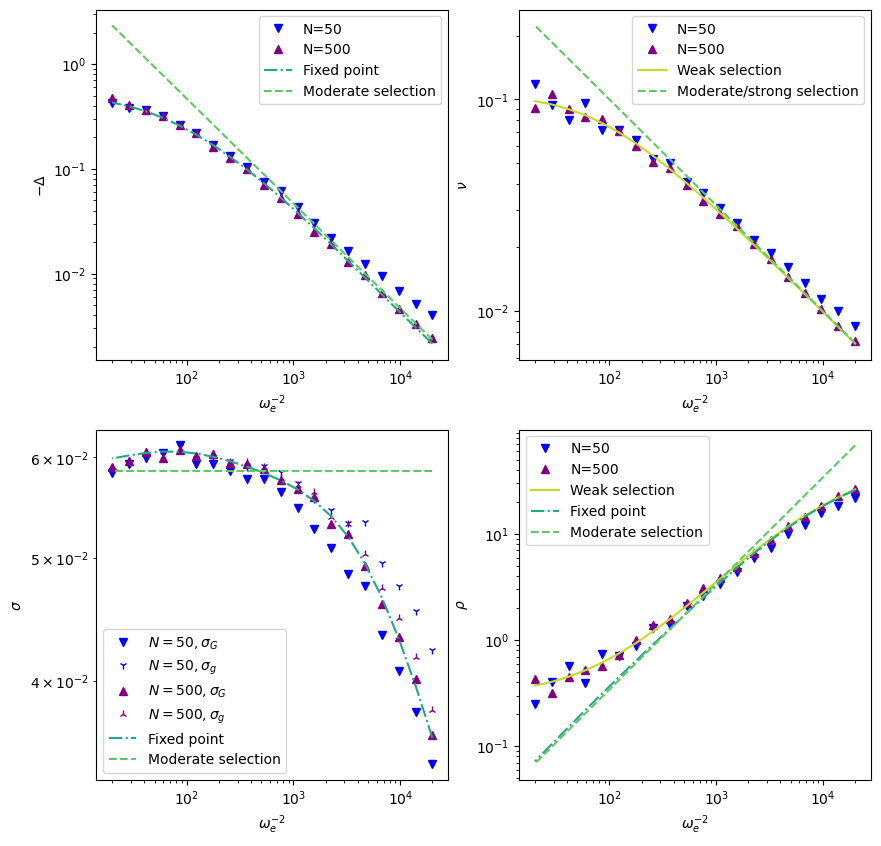

In [7]:
#Plots !
fig,ax = plt.subplots(2,2,figsize=(10,10))
listcolors=plt.get_cmap("viridis")

##### PLOTTING DELTA #####
ax[0,0].set_xscale("log")
ax[0,0].set_yscale("log")
####Simulations####
line1 = ax[0,0].plot(omem2,list_means,"v",label="N="+str(N),color="blue")
line2 = ax[0,0].plot(omem22,list_means2,"^",label="N="+str(N2),color="purple")

####Predictions####

line4 = ax[0,0].plot(omem2,-list_delta_strong,label="Fixed point",color=listcolors(0.6),ls="-.")
line5 = ax[0,0].plot(omem2,-list_delta_ms,label="Moderate selection",color=listcolors(.75),ls="--")
ax[0,0].set_xlabel(r"$\omega_e^{-2}$")
ax[0,0].set_ylabel(r"$-\Delta$")
ax[0,0].legend()

##### PLOTTING SIGMA #####
ax[1,0].set_xscale("log")
ax[1,0].set_yscale("log")
transparency=1

####Simulations####
ax[1,0].plot(omem2,np.sqrt(list_meanvars),marker="v",label=r"$N=$"+str(N)+r"$, \sigma_G$",ls="",color="blue",alpha=transparency)
#If we neglect linkage, then we expect Var[z] = 2 L E[alpha**2 X(1-X)] = 2 list_meanvarsX
ax[1,0].plot(omem2,np.sqrt(2*list_meanvarsX),marker="1",label=r"$N=$"+str(N)+r"$, \sigma_g$",ls="",color="blue",alpha=transparency)
ax[1,0].plot(omem22,np.sqrt(list_meanvars2),marker="^",label=r"$N=$"+str(N2)+r"$, \sigma_G$",ls="",color="purple",alpha=transparency)
ax[1,0].plot(omem22,np.sqrt(2*list_meanvarsX2),marker="2",label=r"$N=$"+str(N2)+r"$, \sigma_g$",ls="",color="purple",alpha=transparency)

####Predictions####
ax[1,0].loglog(omem2,np.sqrt(sigma2_th_fp), label="Fixed point",color=listcolors(.6),alpha=transparency,ls="-.")
ax[1,0].loglog(omem2,np.sqrt(sigma2_th_ms),label="Moderate selection",color=listcolors(.75),alpha=transparency,ls="--")
ax[1,0].set_xlabel(r"$\omega_e^{-2}$")
ax[1,0].set_ylabel(r"$\sigma$")
ax[1,0].legend()

##### PLOTTING NU #####
#### Simulations ####
ax[0,1].loglog(omem2,np.sqrt(list_varmeans),"v",label="N="+str(N),color="blue")
ax[0,1].loglog(omem22,np.sqrt(list_varmeans2),"^",label="N="+str(N2),color="purple")

#### Predictions ####
ax[0,1].loglog(omem2,nu_corrected,label="Weak selection",color=listcolors(.9),ls="-")
ax[0,1].loglog(omem2,nu,label="Moderate/strong selection",color=listcolors(.75),ls="--")

ax[0,1].legend()
ax[0,1].set_xlabel(r"$\omega_e^{-2}$")
ax[0,1].set_ylabel(r"$\nu$")

##### PLOTTING 2N RHO #####
#### Simulations ####
ax[1,1].loglog(omem2,2*N*list_rho,"v",label="N="+str(N),color="blue")
ax[1,1].loglog(omem22,2*N2*list_rho2,"^",label="N="+str(N2),color="purple")

#### Predictions ####
ax[1,1].loglog(omem2,correctedrho2N_th,label="Weak selection",color=listcolors(0.9),ls="-")
ax[1,1].loglog(omem2,rho2N_th_fp,label="Fixed point",color=listcolors(0.6),ls="-.")
ax[1,1].loglog(omem2,rho2N_th_ms,label="Moderate selection",color=listcolors(0.75),ls="--")
ax[1,1].set_xlabel(r"$\omega_e^{-2}$")
ax[1,1].set_ylabel(r"$\rho$")
ax[1,1].legend()


plt.savefig("Fig_2.pdf")

## Phase transition in the limit (Figure 3)
Here, we generate Fig.3, showing the expected limit behavior when $L$ and $N$ are truly infinite.
### Figure 3.A-C

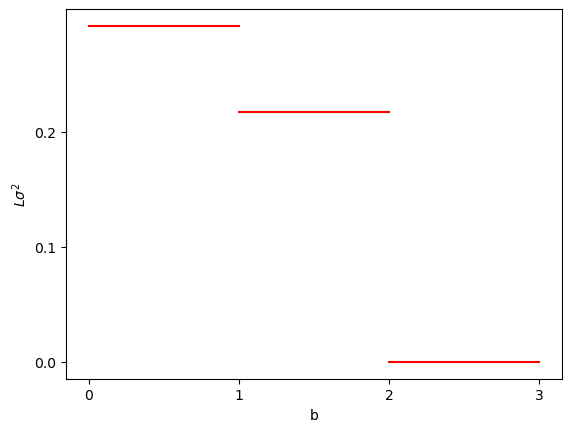

In [9]:
theta = (0.1,0.1)
eta = 1.5
L=100
list_alpha = np.load("alpha100.npy",allow_pickle=True)
list_proba_alpha = np.ones(L)/L


sigma2_0 = genetic_variance_ms(0,theta,L,list_alpha,list_proba_alpha)

sstar_ms = solve_ms(theta,eta,L,list_alpha,list_proba_alpha)
sigma2_ms = genetic_variance_ms(sstar_ms,theta,L,list_alpha,list_proba_alpha)

fig,ax = plt.subplots()
ax.plot([0,1],[L*sigma2_0]*2,color="red")
ax.plot([1,2],[L*sigma2_ms]*2,color="red")
ax.plot([2,3],[0]*2,color="red")
ax.set_xticks([0,1,2,3])
ax.set_yticks([0,0.1,0.2])
ax.set_xlabel(r"b")
ax.set_ylabel(r"$L\sigma^2$")
plt.savefig("Fig_3A.pdf")

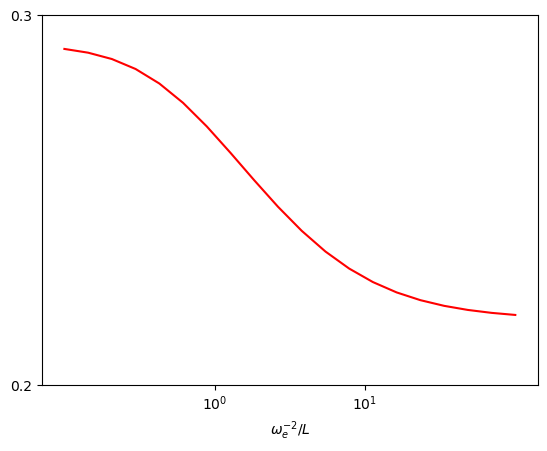

In [10]:
#Weak selection
list_omem2 = np.logspace(-1,2,20)*L #list of selection strengths omega_e^{-2}
sstar_ws = np.zeros(20)
list_sig2 = np.zeros(20)

for (k,omem2) in enumerate(list_omem2):
    sstar_ws[k] = solve_ws(omem2,
                   theta,
                   eta,
                   L,
                   list_alpha,
                   list_proba_alpha,
                   tolerance=1e-5,
                   a0=-1000,
                   b0=1000)
    list_sig2[k] = genetic_variance_ms(sstar_ws[k],theta,L,list_alpha,list_proba_alpha)

fig,ax = plt.subplots()
ax.plot(np.linspace(-1,2,20),L*list_sig2,color="red")
ax.set_xticks([0,1],labels=[r"$10^0$",r"$10^1$"])
ax.set_yticks([0.2,0.3])
ax.set_xlabel(r"$\omega_e^{-2}/L$")
plt.savefig("Fig_3B.pdf")

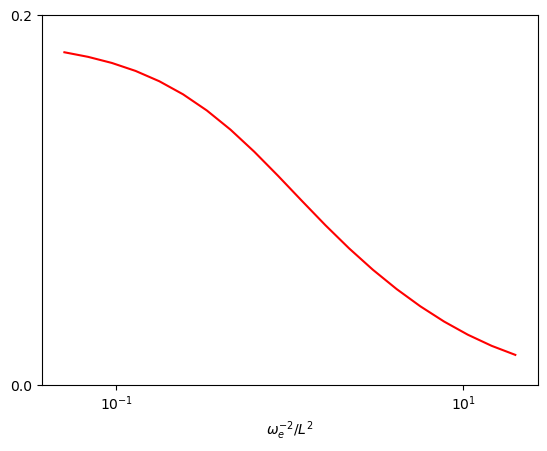

In [11]:
#Strong selection
list_omem2 = np.logspace(-1.3,1.3,20)*L**2 #list of selection strengths omega_e^{-2}
list_sig2 = np.zeros(20)
for (k,omem2) in enumerate(list_omem2):
    list_sig2[k] = genetic_variance_fp_sm(sstar_ms,omem2,theta,L,list_alpha,list_proba_alpha)

fig,ax = plt.subplots()
ax.plot(np.linspace(-1.3,1.3,20),L*list_sig2,color="red")
ax.set_xticks([-1,1],labels=[r"$10^{-1}$",r"$10^1$"])
ax.set_yticks([0,0.2])
ax.set_xlabel(r"$\omega_e^{-2}/L^2$")
plt.savefig("Fig_3C.pdf")

### Figure 3.D-F

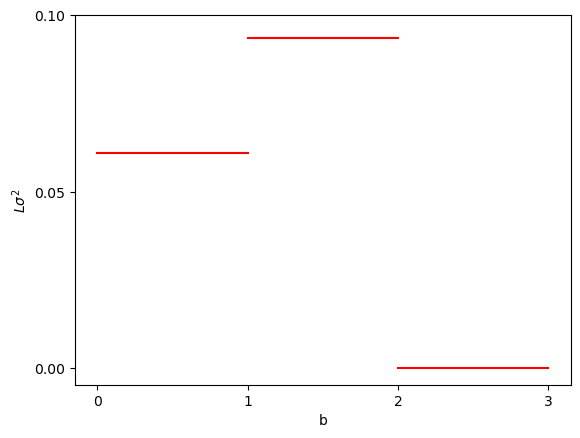

In [12]:
theta = (0.01,0.1)
sigma2_0 = genetic_variance_ms(0,theta,L,list_alpha,list_proba_alpha)

sstar_ms = solve_ms(theta,eta,L,list_alpha,list_proba_alpha)
sigma2_ms = genetic_variance_ms(sstar_ms,theta,L,list_alpha,list_proba_alpha)

fig,ax = plt.subplots()
ax.plot([0,1],[L*sigma2_0]*2,color="red")
ax.plot([1,2],[L*sigma2_ms]*2,color="red")
ax.plot([2,3],[0]*2,color="red")
ax.set_xticks([0,1,2,3])
ax.set_yticks([0,0.05,0.10],labels=["0.00","0.05","0.10"])
ax.set_xlabel(r"b")
ax.set_ylabel(r"$L\sigma^2$")

plt.savefig("Fig_3D.pdf")

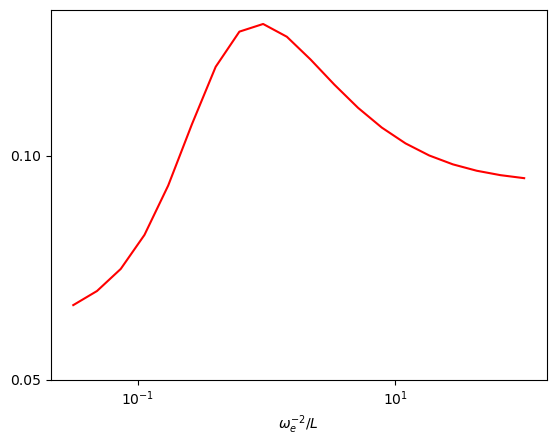

In [13]:
#Weak selection
list_omem2 = np.logspace(-1.5,2,20)*L #list of selection strengths omega_e^{-2}
sstar_ws = np.zeros(20)
list_sig2 = np.zeros(20)

for (k,omem2) in enumerate(list_omem2):
    sstar_ws[k] = solve_ws(omem2,
                   theta,
                   eta,
                   L,
                   list_alpha,
                   list_proba_alpha,
                   tolerance=1e-5,
                   a0=-1000,
                   b0=1000)
    list_sig2[k] = genetic_variance_ms(sstar_ws[k],theta,L,list_alpha,list_proba_alpha)

fig,ax = plt.subplots()
ax.plot(np.linspace(-1.5,2,20),L*list_sig2,color="red")
ax.set_xticks([-1,1],labels=[r"$10^{-1}$",r"$10^1$"])
ax.set_yticks([0.05,0.1])
ax.set_xlabel(r"$\omega_e^{-2}/L$")
plt.savefig("Fig_3E.pdf")

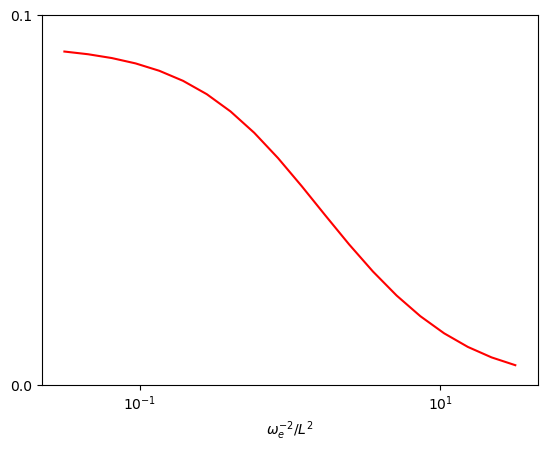

In [14]:
#Strong selection
list_omem2 = np.logspace(-1.5,1.5,20)*L**2 #list of selection strengths omega_e^{-2}
list_sig2 = np.zeros(20)
for (k,omem2) in enumerate(list_omem2):
    list_sig2[k] = genetic_variance_fp_sm(sstar_ms,omem2,theta,L,list_alpha,list_proba_alpha)

fig,ax = plt.subplots()
ax.plot(np.linspace(-1.5,1.5,20),L*list_sig2,color="red")
ax.set_xticks([-1,1],labels=[r"$10^{-1}$",r"$10^1$"])
ax.set_yticks([0,0.1])
ax.set_xlabel(r"$\omega_e^{-2}/L^2$")
plt.savefig("Fig_3F.pdf")

## Histogram of mean trait value (Figure 4)
Here, we generate Fig.2 showing a histogram of the mean trait value distribution at stationarity for various selection regimes.

In [15]:
#Parameters
eta=1.2
L=100
N=500
listx = np.linspace(0.8,1.3,100)

postburnin=5000 #Only look at the 1000 last positions
np.random.seed(0)

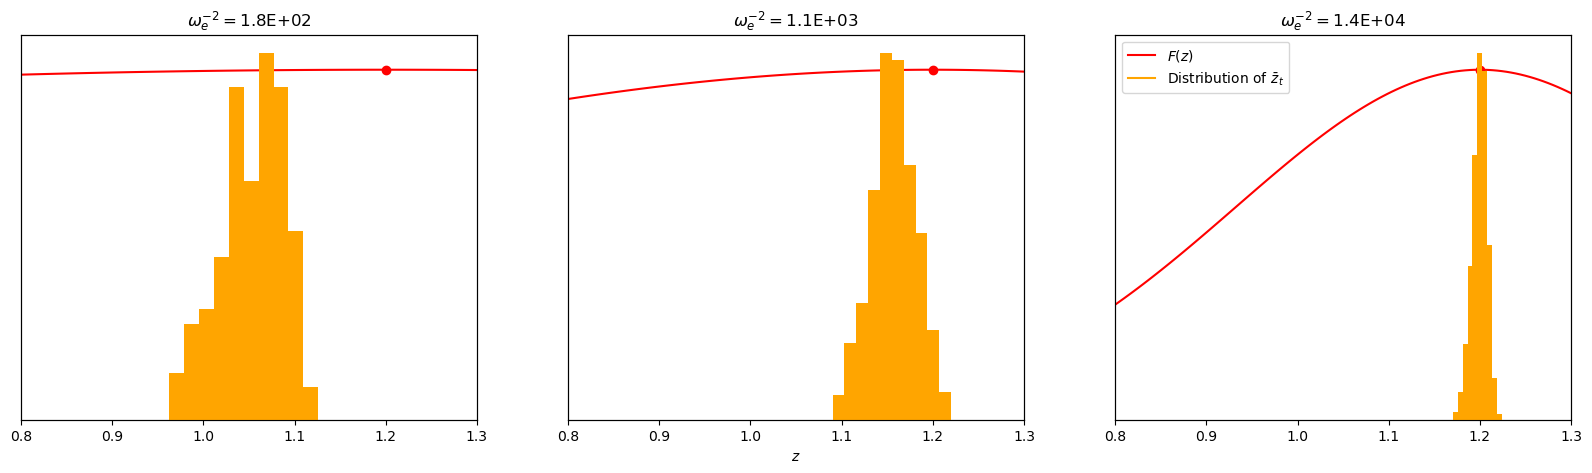

In [16]:
fig,ax=plt.subplots(1,3,figsize=(20,5))
ax2 = [0]*3
sim_numbers = [13,8,1] #We will take simulation number 13 as a reference of weak selection, 8 for moderate etc.
for k in range(3):
    tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(sim_numbers[k])+".npy",allow_pickle=True)
    omega = tmp[0]
    list_means = tmp[3][-postburnin:]
    #plt.subplot(131+k)
    ax2[k] = ax[k].twinx()
    ax2[k].hist(list_means,density=True,label=r"Distribution of $\bar z_t$",color="orange")
    ax[k].plot(listx,np.exp(-(listx-eta)**2/(2*omega**2)),color="red",label=r"$F(z)$")
    ax[k].plot([eta],[1],marker="o",color="red")
    ax[k].set_ylim(0,1.1)
    ax[k].yaxis.set_visible(False)
    ax2[k].yaxis.set_visible(False)
    ax[k].set_xlim(listx[0],listx[-1])
    ax[k].set_title(r"$\omega_e^{-2}=$"+"{0:.1E}".format(2*N/omega**2))

ax[2].plot([1],color="orange",label=r"Distribution of $\bar z_t$")
ax[2].legend()
ax[1].set_xlabel(r"$z$")
plt.savefig("Fig_4.pdf")

## Impossibility to detect selection (Figure 5)

In [19]:
#Parameters
theta= (.1,.2)
eta=1.2
L=100
list_alpha = np.load("alpha100.npy",allow_pickle=True)
list_proba_alpha = np.ones(L)/L

klim = 81 #Degree of precision for the theoretical computations under strong selection
#If klim is too low then the genetic variance sigma2_th_fp will have a bump for strong selection

In [20]:
burn_in = 1/2 #We consider that the system reaches stationarity after a fraction burn_in of the time
########## LOADING N=50 #########
N=50
nbpoints=20

omega = np.zeros(nbpoints)
list_means = np.zeros(nbpoints)
list_meanvarsX = np.zeros(nbpoints) #L E[alpha**2 X(1-X)]
list_meanvars = np.zeros(nbpoints) #trait variance with linkage

tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(0)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))

for k in range(nbpoints):
    tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(k)+".npy",allow_pickle=True)
    omega[k] = tmp[0]
    list_means[k] = eta-np.mean(tmp[3][-postburnin:])
    list_meanvarsX[k] = np.mean(tmp[4][-postburnin:])
    list_meanvars[k] = np.mean(tmp[5][-postburnin:])

omem2 = 2*N/omega**2 #Selection strength = $omega_e^{-2}$


In [21]:
########## LOADING N=500 #########
N2=500
nbpoints2=20

omega2 = np.zeros(nbpoints2)
list_means2 = np.zeros(nbpoints2)
list_meanvarsX2 = np.zeros(nbpoints2) #L E[alpha**2 X(1-X)]
list_meanvars2 = np.zeros(nbpoints2) #trait variance with linkage
list_rsq = np.zeros(nbpoints2) #r2 of log-autocorrelation

tmp = np.load("sims_L"+str(L)+"_N"+str(N2)+"/"+str(0)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))
for k in range(nbpoints2):
    tmp = np.load("sims_L"+str(L)+"_N"+str(N2)+"/"+str(k)+".npy",allow_pickle=True)
    omega2[k] = tmp[0]
    list_means2[k] = eta-np.mean(tmp[3][-postburnin:])
    list_varmeans2[k] = np.var(tmp[3][-postburnin:],ddof=1)
    list_rho2[k] = -np.log(np.cov(tmp[3][-postburnin-1:-1],tmp[3][-postburnin:])[0,1]/list_varmeans2[k])
    list_meanvarsX2[k] = np.mean(tmp[4][-postburnin:])
    list_varvarsX2[k] = np.var(tmp[4][-postburnin:],ddof=1)
    list_meanvars2[k] = np.mean(tmp[5][-postburnin:])
    list_varvars2[k] = np.var(tmp[5][-postburnin:],ddof=1)

tmp = None

omem22 = 2*N2/omega2**2 #This is the strength of selection omega_e^{-2}

In [22]:
#### Predictions ####
###Selection coefficients ###
#Moderate selection
sstar_ms = solve_ms(theta,eta,L,list_alpha,list_proba_alpha)

#Fixed point
sstar_fp = np.array([solve_fp(omem2[k],
                                     theta,
                                     eta,
                                     L,
                                     list_alpha,
                                     list_proba_alpha,
                                     klim=klim)
             for k in range(nbpoints)])

### Observables ###
#Delta
list_delta_strong = -omega**2 * sstar_fp/(2*N)
list_delta_ms = -omega**2 * sstar_ms/(2*N)

#Sigma
sigma2_th_fp = np.array([ #fixed_point
                      genetic_variance_fp(sstar_fp[k],
                                              omem2[k],
                                              theta,
                                              L,
                                              list_alpha,
                                              list_proba_alpha,
                                              klim=klim)
                      for k in range(nbpoints)])


sigma2_th_ms = genetic_variance_ms(sstar_ms,theta,L,list_alpha,list_proba_alpha)*np.ones(nbpoints)

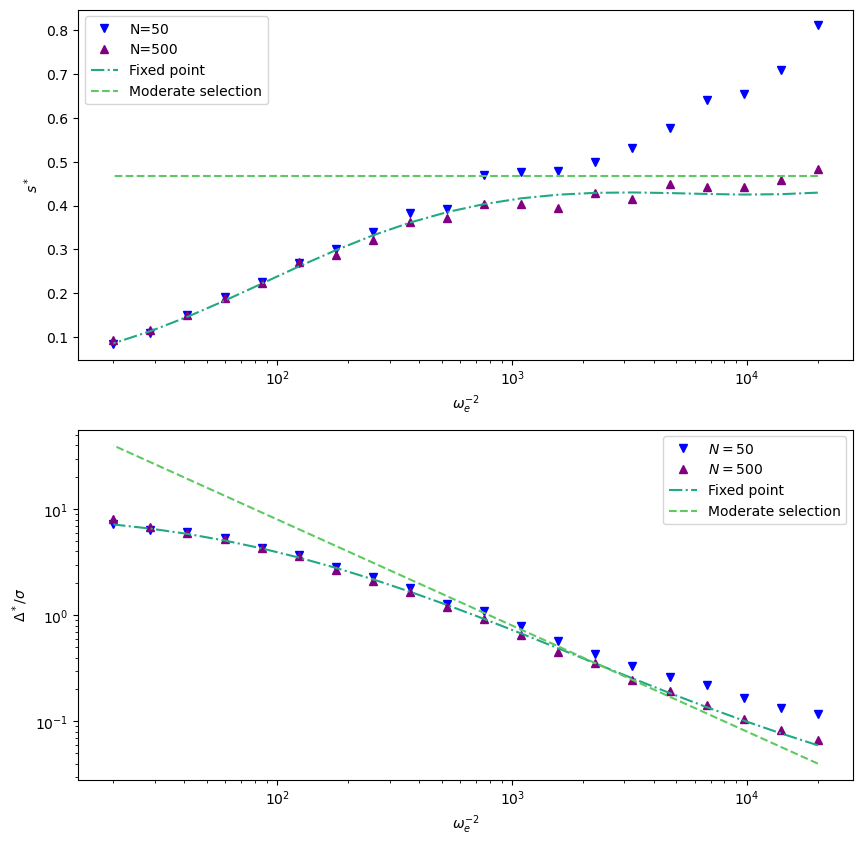

In [23]:
#Plots !
fig,ax = plt.subplots(2,figsize=(10,10))
listcolors=plt.get_cmap("viridis")

##### PLOTTING DELTA #####
ax[0].set_xscale("log")
####Simulations####
line1 = ax[0].plot(omem2,list_means/L*omem2,"v",label="N="+str(N),color="blue")
line2 = ax[0].plot(omem22,list_means2/L*omem2,"^",label="N="+str(N2),color="purple")

####Predictions####
line4 = ax[0].plot(omem2,-list_delta_strong/L*omem2,label="Fixed point",color=listcolors(0.6),ls="-.")
line5 = ax[0].plot(omem2,-list_delta_ms/L*omem2,label="Moderate selection",color=listcolors(.75),ls="--")
ax[0].set_xlabel(r"$\omega_e^{-2}$")
ax[0].set_ylabel(r"$s^*$")
ax[0].legend()

##### PLOTTING SIGMA #####
ax[1].set_xscale("log")
transparency=1

####Simulations####
ax[1].plot(omem2,list_means/np.sqrt(list_meanvars),marker="v",
           label=r"$N=$"+str(N),ls="",color="blue",alpha=transparency)
#If we neglect linkage, then we expect Var[z] = 2 L E[alpha**2 X(1-X)] = 2 list_meanvarsX
ax[1].plot(omem22,list_means2/np.sqrt(list_meanvars2),marker="^",
           label=r"$N=$"+str(N2),ls="",color="purple",alpha=transparency)

####Predictions####
ax[1].loglog(omem2,-list_delta_strong/np.sqrt(sigma2_th_fp), 
             label="Fixed point",color=listcolors(.6),alpha=transparency,ls="-.")
ax[1].loglog(omem2,-list_delta_ms/np.sqrt(sigma2_th_ms),
             label="Moderate selection",color=listcolors(.75),alpha=transparency,ls="--")
ax[1].set_xlabel(r"$\omega_e^{-2}$")
ax[1].set_ylabel(r"$\Delta^*/\sigma$")
ax[1].legend()
plt.savefig("Fig_5.pdf")

## Theoretical distribution of allele frequencies vs simulations (Figure 6)
Here we generate Fig.5 about the joint distribution of $(\alpha,P_t)$.

In [17]:
#Parameters
listcolors=plt.get_cmap("viridis")

theta = (.5,.5)
eta=1.2
L=100
N=500
list_alpha = np.linspace(0,6/L,L) #numerical instabilities if we allow alpha too large
list_density_alpha = L*np.exp(-L*list_alpha)
list_proba_alpha = list_density_alpha/np.sum(list_density_alpha)


listx = np.linspace(1/(2*N),1-1/(2*N),2*N)

nlevels = 20 #How many levels for the contourplot ?

nbsims = 4

vmax = 100


omega = np.zeros(nbsims)
inflation = 100
listx = np.linspace(1/(inflation*N),1-1/(inflation*N),inflation*N)

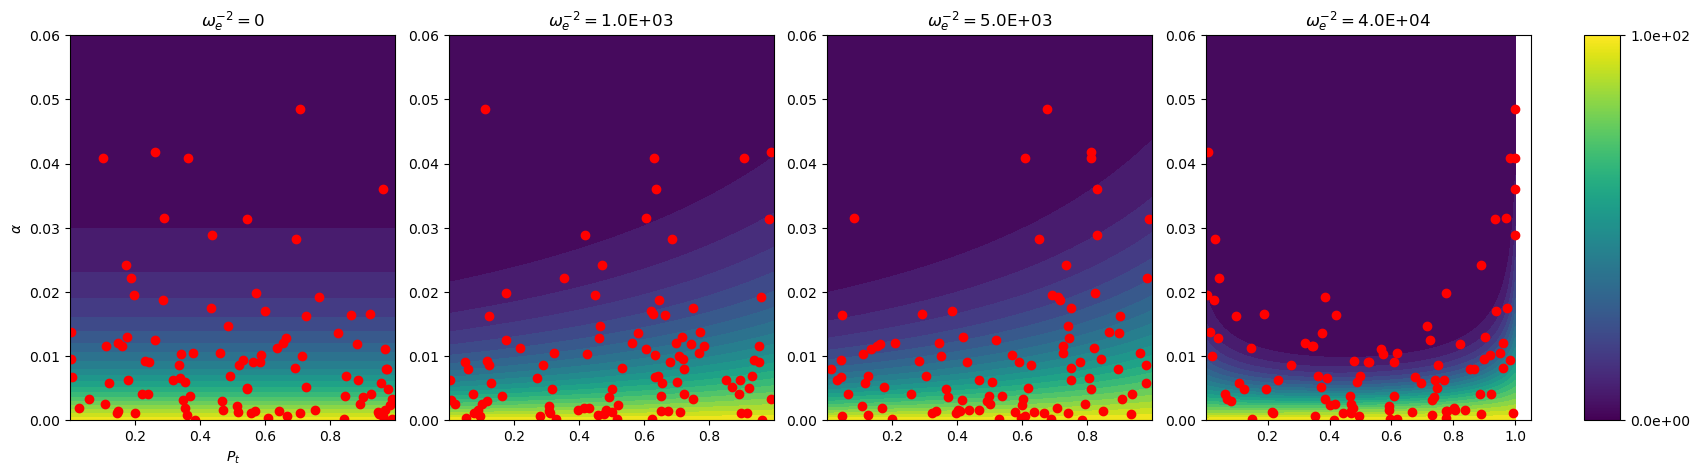

In [18]:
fig,ax=plt.subplots(1,nbsims+1,figsize=(20,5),gridspec_kw={'width_ratios': [3,3,3,3, 1/3]})
omega = np.zeros(nbsims)

#### Simulations ####
for k in np.arange(nbsims):
    tmp = np.load("contoursims/sims_L"+str(L)+"_N"+str(N)+"/"+str(k)+".npy",allow_pickle=True)
    omega[k] = tmp[0]
    allele_freq = tmp[1]
    alphas = tmp[2]
    ax[k].plot(allele_freq,alphas,"o",color="red")

omem2 = 2*N/(omega**2)

#### Predictions ####
#NEUTRAL DISTRIBUTION
neutral_distrib = np.ones(len(listx)) #When theta= (.5,.5)
Zw=np.zeros((L,inflation*N))
for (kalpha,alpha) in enumerate(list_alpha):
    Zw[kalpha] = neutral_distrib*list_density_alpha[kalpha]
ax[0].contourf(listx,list_alpha,Zw,levels=nlevels,vmin=0,vmax=vmax)

#WEAK SELECTION
sstar_weak = solve_fp(omem2[1],theta,eta,L,list_alpha,list_proba_alpha,tolerance=1e-10)

Zm=np.zeros((L,inflation*N))
for (kalpha,alpha) in enumerate(list_alpha):
    Zm[kalpha] = neutral_distrib[k] * np.exp(2*alpha*sstar_weak*listx) * list_density_alpha[kalpha]
    normalization_constant = special.hyp1f1(2*theta[0],2*(theta[0]+theta[1]),2*alpha*sstar_weak)
    Zm[kalpha] /= normalization_constant
ax[1].contourf(listx,list_alpha,Zm,levels=nlevels,vmin=0,vmax=vmax)

#MODERATE SELECTION
sstar_moderate = solve_ms(theta,eta,L,list_alpha,list_proba_alpha)
Zs=np.zeros((L,inflation*N))
for (kalpha,alpha) in enumerate(list_alpha):
    s_ell = alpha*sstar_moderate*listx
    Zs[kalpha] = neutral_distrib[k] * np.exp(2*s_ell) * list_density_alpha[kalpha]
    normalization_constant = special.hyp1f1(2*theta[0],2*(theta[0]+theta[1]),2*alpha*sstar_moderate)
    Zs[kalpha] /= normalization_constant
ax[2].contourf(listx,list_alpha,Zs,levels=nlevels,vmin=0,vmax=vmax)

#STRONG SELECTION
Zs=np.zeros((L,inflation*N))
sstar_strong = solve_fp(omem2[3],theta,eta,L,list_alpha,list_proba_alpha)
for (kalpha,alpha) in enumerate(list_alpha):
    s_ell = alpha*sstar_strong*listx - alpha**2 * 2*N * 1/omega[3]**2 *listx*(1-listx)
    Zs[kalpha] = neutral_distrib[k] * np.exp(2*s_ell) * list_density_alpha[kalpha]
    normalization_constant = special.hyp1f1(2*theta[0],2*(theta[0]+theta[1]),2*alpha*sstar_moderate)
    Zs[kalpha] /= normalization_constant
ax[3].contourf(listx,list_alpha,Zs,levels=nlevels,vmin=0,vmax=vmax)

########## Final plot details
ax[0].set_xlabel(r"$P_t$")
ax[0].set_ylabel(r"$\alpha$")

ax[0].set_title(r"$\omega_e^{-2}=0$")
for k in range(1,nbsims):
    ax[k].set_title(r"$\omega_e^{-2}=$"+"{0:.1E}".format(omem2[k]))


#Colorbar
# Normalizer
norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=listcolors, norm=norm)
sm.set_array([])
plt.colorbar(sm,cax=ax[4],ticks=(0,vmax),format=("%.1e"),label="")

plt.savefig("Fig_6.pdf")

 ## The infinitesimal model (Figure 7)
 Here, we show how taking two genomes randomly at equilibrium, the distribution of their offspring is close to normal.

In [2]:
param,allele_freq,traitmeans,population = np.load("sim_slowfast.npy",allow_pickle=True)
L,N,theta,omega,eta,list_alpha = param
ome2 = omega**2/(2*N) #omega_e^{-2}
nbo = 10000 #Number of offspring from which to obtain the distribution

In [3]:
def free_recombi(g1,g2,L):
    """
    Generates an offspring from genomes g1 and g2 under free recombination.
    Parameters
    ----------
        g1,g2: L*2 boolean arrays
        L: number of loci
    Returns
    -------
        a (2,L) boolean array
    """
    inds = np.random.randint(2,size=(2,L))
    n = np.sum(inds,axis=1)
    i1,i2 = np.random.randint(2,size=2)
    g3 = np.zeros((L,2))
    g3[np.where(inds[0]),np.repeat(0,n[0])] = g1[np.where(inds[0]),np.repeat(i1,n[0])]
    g3[np.where(1-inds[0]),np.repeat(0,L-n[0])] = g1[np.where(1-inds[0]),np.repeat(1-i1,L-n[0])]
    g3[np.where(inds[1]),np.repeat(1,n[1])] = g2[np.where(inds[1]),np.repeat(i2,n[1])]
    g3[np.where(1-inds[1]),np.repeat(1,L-n[1])] = g2[np.where(1-inds[1]),np.repeat(1-i2,L-n[1])]
    return g3

def single_co(g1,g2,L):
    """
    Generates an offspring from genomes g1 and g2 under single-point crossover recombination.
    Parameters
    ----------
        g1,g2: L*2 boolean arrays
    """
    U = np.random.randint(L,size=2)
    i = np.random.randint(2,size=2)
    g3 = np.zeros((L,2))
    g3[:U[0],0] = g1[:U[0],i[0]]
    g3[U[0]:,0] = g1[U[0]:,1-i[0]]
    g3[:U[1],1] = g1[:U[1],i[1]]
    g3[U[1]:,1] = g1[U[1]:,1-i[1]]
    return g3


In [4]:
#Script: generating many offspring from two randomly-sampled organisms
np.random.seed(0)
n1,n2 = np.random.choice(N,size=2)
g1 = population[n1]
g2 = population[n2]

#free recombination
list_traits_fr = np.zeros(nbo)
for o in range(nbo):
    g3 = free_recombi(g1,g2,L)
    list_traits_fr[o] = (g3@np.ones(2)) @ list_alpha
#Centering, scaling
list_traits_fr = (list_traits_fr-np.mean(list_traits_fr))/np.sqrt(np.var(list_traits_fr,ddof=1))

#single-point crossover
list_traits_sc = np.zeros(nbo)
for o in range(nbo):
    g3 = single_co(g1,g2,L)
    list_traits_sc[o] = (g3@np.ones(2)) @ list_alpha
#Centering, scaling
list_traits_sc = (list_traits_sc-np.mean(list_traits_sc))/np.sqrt(np.var(list_traits_sc,ddof=1))

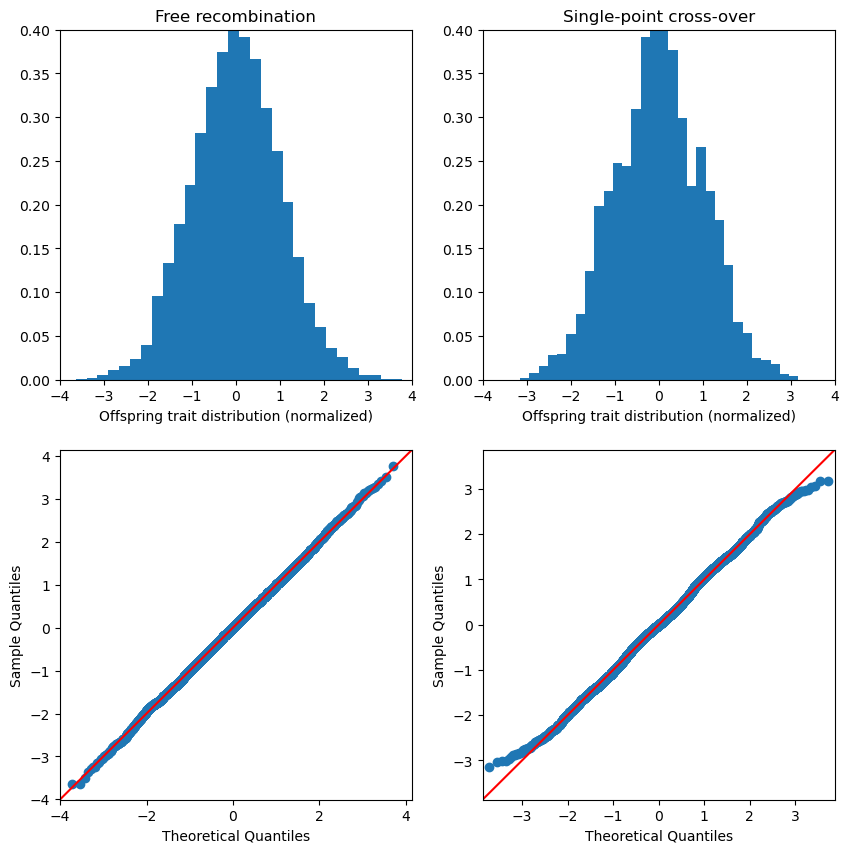

In [5]:
import statsmodels.graphics.gofplots as smgg

fig,ax=plt.subplots(2,2,figsize=(10,10))
ax[0,0].hist(list_traits_fr,density=True,bins=30)
ax[0,0].set_xlabel("Offspring trait distribution (normalized)")
ax[0,0].set_title("Free recombination")
ax[0,0].set_xlim(-4,4)
ax[0,0].set_ylim(0,0.4)
smgg.qqplot(list_traits_fr,line='45',ax=ax[1,0])

ax[0,1].hist(list_traits_sc,density=True,bins=30)
ax[0,1].set_xlabel("Offspring trait distribution (normalized)")
ax[0,1].set_title("Single-point cross-over")
ax[0,1].set_xlim(-4,4)
ax[0,1].set_ylim(0,0.4)
smgg.qqplot(list_traits_sc,line='45',ax=ax[1,1])

plt.savefig("Fig_7.pdf")


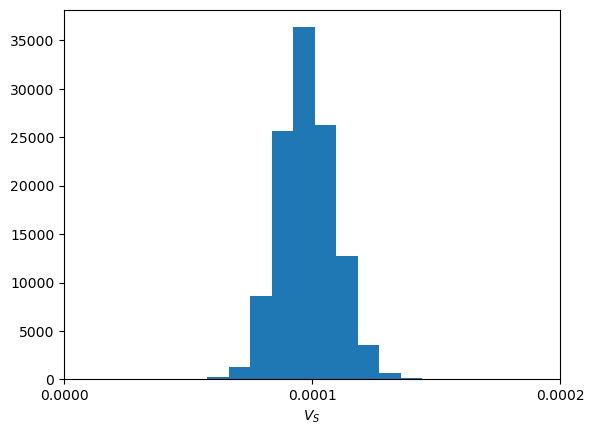

In [7]:
#Script: plotting the distribution of segregation variance
distrib_VS = np.zeros(N)
k=0
for i in range(N):
        distrib_VS[i] = np.sum((list_alpha *(population[i,:,0]*1-population[i,:,1]))**2)/4

fig,ax = plt.subplots()
ax.set_xlim(0,0.0002)
ax.set_xticks((0,0.0001,0.0002))
ax.set_xlabel(r"$V_S$")
ax.hist(distrib_VS,density=True)
plt.show()

# Appendix
We now generate the figures in the Appendix.

## Boxplotting the marginal fitness of an allele  (Figure S1)

In [29]:
from simulate_population import Population

In [30]:
#Parameters

eta = 1.2
T= 100
N=100
L=100 #Must be a multiple of 100 for technical reasons
theta = (.1,.2) # The rate of mutation from 0 to +1 is thetaN[0]/N per organism
                 # per generation per locus

list_alpha = np.load("alpha100.npy",allow_pickle=True)

omem2 = 2*L**2 #Selection strength $=omega_e^{-2}$ (strong selection)
omega = np.sqrt(2*N/(2*L**2)) 

In [31]:
# Simulation
np.random.seed(0)
np.random.shuffle(list_alpha)
pop = Population(theta,N,L,alpha=list_alpha)
for t in range(T*N):
    pop.selection_drift_sex(omega,eta,N,L)
    pop.mutation(theta,N,L)

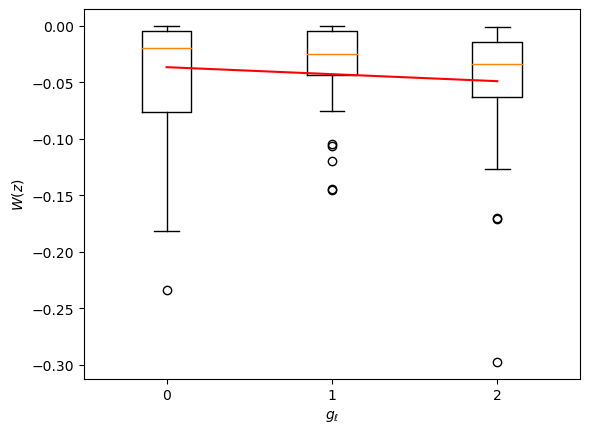

In [32]:
# Plot
ell = 3
gene_content = np.sum(pop.population[:,ell,:],axis=-1) #gene content at locus ell
fitnesses = np.log(pop.fitness(omega,eta,L))
fitness_classes = [fitnesses[gene_content==0],fitnesses[gene_content==1],fitnesses[gene_content==2]]

regression_coefficient = np.cov(gene_content,fitnesses)[0,1]/np.var(gene_content,ddof=1)
intercept = np.mean(fitnesses) - regression_coefficient*np.mean(gene_content)

plt.boxplot(fitness_classes,labels=[0,1,2])
plt.plot(np.arange(1,4),intercept + regression_coefficient*np.arange(3),color="red")

plt.ylabel(r"$W(z)$")
plt.xlabel(r"$g_\ell$")
plt.savefig("Fig_S1.pdf")

## Illustrating the slow/fast principle (Fig. S2)

In [8]:
param,allele_freq,traitmeans,population = np.load("sim_slowfast.npy",allow_pickle=True)
L,N,theta,omega,eta,list_alpha = param
ome2 = omega**2/(2*N) #omega_e^{-2}

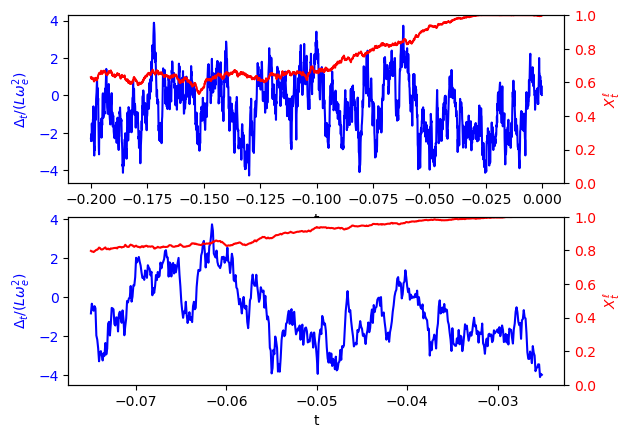

In [16]:
####Plot####
ell = 4 #locus monitored

fig, ax1 = plt.subplots(2)
t0,t1 = (-2000,-1)
list_t = np.arange(t0,t1)/(2*N)
ax1[0].set_xlabel('t')
ax1[0].set_ylabel(r'$\Delta_t/(L\omega_e^2)$', color = 'blue')
ax1[0].plot(list_t,traitmeans[t0:t1]/(L*ome2), color = 'blue')
ax1[0].tick_params(axis ='y', labelcolor = 'blue')

# Adding Twin Axes
ax2 = ax1[0].twinx()

ax2.set_ylabel(r'$X_t^\ell$', color = 'red')
ax2.set_ylim((0,1))
ax2.plot(list_t,allele_freq[t0:t1,ell], color = 'red')
ax2.tick_params(axis ='y', labelcolor = 'red')

### Zoom in ###
t0,t1 = (-3 * 2000//8,-2000//8)
list_t = np.arange(t0,t1)/(2*N)
ax1[1].set_xlabel('t')
ax1[1].set_ylabel(r'$\Delta_t/(L\omega_e^2)$', color = 'blue')
ax1[1].plot(list_t,traitmeans[t0:t1]/(L*ome2), color = 'blue')
ax1[1].tick_params(axis ='y', labelcolor = 'blue')

# Adding Twin Axes
ax2 = ax1[1].twinx()

ax2.set_ylabel(r'$X_t^\ell$', color = 'red')
ax2.set_ylim((0,1))
ax2.plot(list_t,allele_freq[t0:t1,ell], color = 'red')
ax2.tick_params(axis ='y', labelcolor = 'red')

plt.savefig("Fig_S2.pdf")

## The breakdown due to the Hill-Robertson effect (Fig. S3-S4)
### Simulating directional selection.
To illustrate the breakdown due to the Hill-Robertson effect, we first need to simulate a population evolving under directional selection.

In [35]:
from simulate_population import *

In [36]:
class Population_dir():
    """A population under directional selection has
    population : a (N,L,2) matrix of bools representing the L genes of each of the N diploid
                    organisms
    meantrait: mean trait value in the population
    vartrait: variance in trait value in the population
    alpha : a string of L floats representing the additive effects at each locus (picked at
            the beginning and then fixed)
            We recommand that alpha be of order 1/L when the mutation optimum eta is of order 1.
    """
    def __init__(self,theta,N,L,population=None,alpha=None):
        """Population is initialized from
            Parameters
        ----------
        N (int): the population size
        L (int): the number of loci
        theta (positive float array of size 2): denotes the relative balance of 1 and 0 in the population if 
                                                it is generated using generate_pop
        """
        self.alpha=alpha
        if population is None:
            population = generate_pop(theta,N,L)
        self.population = population
        self.meantraits = None
        self.vartraits = None

    def trait(self):
        """Returns an array of size N of trait values within the population"""
        return (self.population@np.ones(2)) @ self.alpha

    def fitness(self,s,L):
        """Returns an array of size N of fitness values within the population 
        Parameters
        ----------
        s (float): the strength of directional selection
        L (int): the number of loci
        """
        return np.exp(s*self.trait())

    def allele_frequencies(self):
        """Returns an array of size L of frequencies of trait-increasing alleles within the population"""
        return np.mean(self.population,axis=(0,2))

    def mutation(self,theta,N,L):
        """Mutation works by sampling a Poisson number of genes and
        mutating them.
        The mutation probability from 0 to +1 (resp. +1 to 0) is theta[0]/(2N) (resp. theta[1]/(2N)) per
        generation per locus per haploid organism.
        Parameters
        ----------
        theta (positive float array of size 2): the mutation rate. The probability of mutation from 0 to +1 
                (resp. +1 to 0) is theta[0]/(2N) (resp. theta[1]/(2N))
        N (int): the population size
        L (int): the number of loci"""
        number_of_mutations=np.random.poisson(L*(theta[0]+theta[1]))
        mutated_indexes= (np.random.randint(N,size=number_of_mutations),
                          np.random.randint(L,size=number_of_mutations),
                          np.random.randint(2,size=number_of_mutations))
        self.population[mutated_indexes]=generate_mutated(number_of_mutations,theta)

    def selection_drift_sex(self,s,N,L):
        """
        Generates a new population by sampling N offspring from the current population.
        For each offspring we sample two parents proportionnally
        to fitness, and recombine their genomes with a single uniform crossover.
        Parameters
        ----------
        s (float): the strength of directional selection
        N (int): the population size
        L (int): the number of loci
        """
        population_fitnesses = self.fitness(s,L)
        sum_fitnesses = np.sum(population_fitnesses)
        population_fitnesses = population_fitnesses/sum_fitnesses

        list_parents = np.random.choice(N,p=population_fitnesses,size=2*N)
        list_crossing_overs = np.random.randint(L,size=2*N)
        list_chromosome_shuffling = np.random.randint(2,size=2*N)
        new_population = np.array([[[False]*2]*L]*N,dtype="bool")
        for n in range(N):
            parents = (list_parents[2*n],list_parents[2*n+1])

            new_genome = np.zeros((L,2),dtype="bool")

            crossing_over = list_crossing_overs[2*n:2*n+2]
            new_population[n,:,0] = np.append(
                                        self.population[parents[0],
                                                        :crossing_over[0],
                                                        list_chromosome_shuffling[2*n]],
                                        self.population[parents[0],
                                                        crossing_over[0]:,
                                                        1-list_chromosome_shuffling[2*n]]
                                        )
            new_population[n,:,1] = np.append(
                                        self.population[parents[1],
                                                        :crossing_over[1],
                                                        list_chromosome_shuffling[2*n+1]],
                                        self.population[parents[1],
                                                        crossing_over[1]:,
                                                        1-list_chromosome_shuffling[2*n+1]]
                                        )
        self.population = new_population
        self.meantraits = np.mean(self.trait())
        self.vartraits = np.var(self.trait(),ddof=1)

def Simulate_dir(theta,s,N,L,T,initial_pop=None,record_every = 1,alpha=None):
    """Simulates population evolution over time T. Returns vector of allele frequencies.
    Parameters:
    ----------
    theta: mutation rates. The probability of mutation from -1 to +1 is theta[0]/(2N) per locus
            per generation per haploid genome
    s: directional selection strength
    N: diploid population size
    L: number of loci
    T: how long the simulation should last (in units of N)
    recond_every: optional:how often should the population be recorded ?

    Returns:
    list_allele_frequencies,list_varfitnesses,parameters
    """
    nb_timesteps = int(T*N)+1
    list_meantraits = np.zeros(nb_timesteps//record_every)
    list_vartraits = np.zeros(nb_timesteps//record_every)
    list_varX = np.zeros(nb_timesteps//record_every)

    pop = Population_dir(theta,N,L,alpha=alpha,population=initial_pop)

    for tN,t in enumerate(np.linspace(0,T,nb_timesteps)):
        pop.selection_drift_sex(s,N,L)
        pop.mutation(theta,N,L)
        if (tN*100)%(nb_timesteps-1)==0:
            print("Done: "+str((tN*100)//nb_timesteps+1)+" per cent")
        if tN%record_every==0:
            list_meantraits[tN//record_every] = pop.meantraits
            list_vartraits[tN//record_every] = pop.vartraits
            list_varX[tN//record_every] = np.sum(pop.alpha**2
                                           *pop.allele_frequencies()*(1-pop.allele_frequencies()))
    return pop.allele_frequencies(), pop.alpha, list_meantraits, list_varX, list_vartraits

### Dynamical illustration (Fig. S3)

In [37]:
# Parameters
T=1000
burnin = 5000
N=10
L=200
eta=1.2
theta = (.1,.2)

list_alpha = np.load("alpha200.npy",allow_pickle=True)

omem2 = 2/L #Selection strength $=omega_e^{-2}$ (Weak selection)
omega = np.sqrt(2*N/omem2) 

In [38]:
np.random.seed(0)
np.random.shuffle(list_alpha)

pop0 = generate_pop((eta,2-eta),N,L)

sim = Simulate(theta,omega,eta,N,L,T,initial_pop=pop0,alpha=list_alpha)

sstar = -(np.mean(sim[2][-burnin:])-eta)/omega**2

sim_dir = Simulate_dir(theta,sstar,N,L,T,initial_pop=pop0,alpha=list_alpha)

[INFO/MainProcess] Done: 1 per cent
[INFO/MainProcess] Done: 1 per cent
[INFO/MainProcess] Done: 2 per cent
[INFO/MainProcess] Done: 3 per cent
[INFO/MainProcess] Done: 4 per cent
[INFO/MainProcess] Done: 5 per cent
[INFO/MainProcess] Done: 6 per cent
[INFO/MainProcess] Done: 7 per cent
[INFO/MainProcess] Done: 8 per cent
[INFO/MainProcess] Done: 9 per cent
[INFO/MainProcess] Done: 10 per cent
[INFO/MainProcess] Done: 11 per cent
[INFO/MainProcess] Done: 12 per cent
[INFO/MainProcess] Done: 13 per cent
[INFO/MainProcess] Done: 14 per cent
[INFO/MainProcess] Done: 15 per cent
[INFO/MainProcess] Done: 16 per cent
[INFO/MainProcess] Done: 17 per cent
[INFO/MainProcess] Done: 18 per cent
[INFO/MainProcess] Done: 19 per cent
[INFO/MainProcess] Done: 20 per cent
[INFO/MainProcess] Done: 21 per cent
[INFO/MainProcess] Done: 22 per cent
[INFO/MainProcess] Done: 23 per cent
[INFO/MainProcess] Done: 24 per cent
[INFO/MainProcess] Done: 25 per cent
[INFO/MainProcess] Done: 26 per cent
[INFO/MainP

Done: 1 per cent
Done: 1 per cent
Done: 2 per cent
Done: 3 per cent
Done: 4 per cent
Done: 5 per cent
Done: 6 per cent
Done: 7 per cent
Done: 8 per cent
Done: 9 per cent
Done: 10 per cent
Done: 11 per cent
Done: 12 per cent
Done: 13 per cent
Done: 14 per cent
Done: 15 per cent
Done: 16 per cent
Done: 17 per cent
Done: 18 per cent
Done: 19 per cent
Done: 20 per cent
Done: 21 per cent
Done: 22 per cent
Done: 23 per cent
Done: 24 per cent
Done: 25 per cent
Done: 26 per cent
Done: 27 per cent
Done: 28 per cent
Done: 29 per cent
Done: 30 per cent
Done: 31 per cent
Done: 32 per cent
Done: 33 per cent
Done: 34 per cent
Done: 35 per cent
Done: 36 per cent
Done: 37 per cent
Done: 38 per cent
Done: 39 per cent
Done: 40 per cent
Done: 41 per cent
Done: 42 per cent
Done: 43 per cent
Done: 44 per cent
Done: 45 per cent
Done: 46 per cent
Done: 47 per cent
Done: 48 per cent
Done: 49 per cent
Done: 50 per cent
Done: 51 per cent
Done: 52 per cent
Done: 53 per cent
Done: 54 per cent
Done: 55 per cent
Do

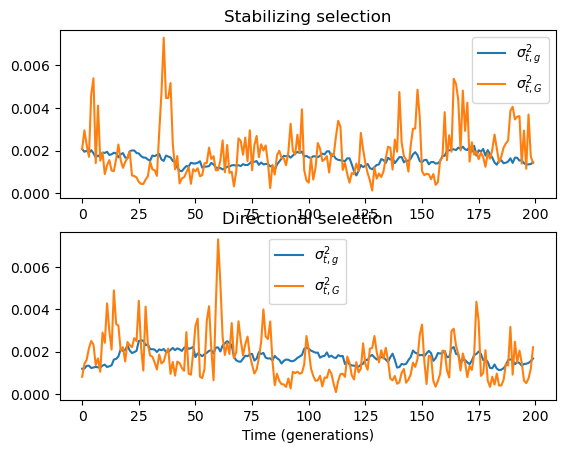

In [39]:
fig,ax = plt.subplots(2)

line1=ax[0].plot(2*sim[3][-300:-100],label=r"$\sigma_{t,g}^2$")
line2=ax[0].plot(sim[4][-300:-100],label=r"$\sigma_{t,G}^2$")
ax[0].legend()
ax[0].set_title("Stabilizing selection")

line3=ax[1].plot(2*sim_dir[3][-300:-100],label=r"$\sigma_{t,g}^2$")
line4=ax[1].plot(sim_dir[4][-300:-100],label=r"$\sigma_{t,G}^2$")
ax[1].legend()
ax[1].set_xlabel("Time (generations)")
ax[1].set_title("Directional selection")

plt.savefig("Fig_S3.pdf")

### Hill-Robertson effect on mean and variance at stationarity (Fig. S4)

In [40]:
#Parameters
listcolors=plt.get_cmap("viridis")

eta=1.2
L=200
#Exponentially distributed genetic effects
#list_alpha = np.linspace(0,6/L,100) #numerical instabilities if we allow alpha too large
#list_proba_alpha = L*np.exp(-L*list_alpha)
#list_proba_alpha /= np.sum(list_proba_alpha)
# We know the distribution of the alphas
list_alpha = np.load("alpha200.npy",allow_pickle=True)
list_proba_alpha = np.ones(L)/L
omem2 = 2*L #Selection strength $=omega_e^{-2}$ (weak selection)
omega = np.sqrt(2*N/omem2)

klim = 81 #Degree of precision for the theoretical computations under strong selection
#If klim is too low then the genetic variance sigma2_th_fp will have a bump for strong selection

In [41]:
# Loading
################################## LOADING ########################################
burn_in = 1/2 #We consider that the system reaches stationarity after a fraction burn_in of the time
########## LOADING N=10 #########
N=10
nbpoints=6

theta = np.zeros((nbpoints,2))
list_means = np.zeros(nbpoints)
list_varmeans = np.zeros(nbpoints)
list_meanvarsX = np.zeros(nbpoints) #L E[alpha**2 X(1-X)]
list_varvarsX = np.zeros(nbpoints) #variance of the previous item
list_meanvars = np.zeros(nbpoints) #trait variance with linkage
list_varvars = np.zeros(nbpoints) #trait variance variance with linkage

tmp = np.load("hitch_hike/sims/theta_0_N"+str(N)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))
for k in range(nbpoints):
    tmp = np.load("hitch_hike/sims/theta_"+str(k)+"_N"+str(N)+".npy",allow_pickle=True)
    theta[k] = tmp[0]
    list_means[k] = eta-np.mean(tmp[3][-postburnin:])
    list_varmeans[k] = np.var(tmp[3][-postburnin:],ddof=1)
    list_meanvarsX[k] = np.mean(tmp[4][-postburnin:])
    list_varvarsX[k] = np.var(tmp[4][-postburnin:],ddof=1)
    list_meanvars[k] = np.mean(tmp[5][-postburnin:])
    list_varvars[k] = np.var(tmp[5][-postburnin:],ddof=1)


thetaplus = np.transpose(theta)[0]


########## LOADING N=30 #########
N3=30

list_means3 = np.zeros(nbpoints)
list_varmeans3 = np.zeros(nbpoints)
list_meanvarsX3 = np.zeros(nbpoints) #L E[alpha**2 X(1-X)]
list_varvarsX3 = np.zeros(nbpoints) #variance of the previous item
list_meanvars3 = np.zeros(nbpoints) #trait variance with linkage
list_varvars3 = np.zeros(nbpoints) #trait variance variance with linkage

tmp = np.load("hitch_hike/sims/theta_0_N"+str(N3)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))

for k in range(nbpoints):
    tmp = np.load("hitch_hike/sims/theta_"+str(k)+"_N"+str(N3)+".npy",allow_pickle=True)
    list_means3[k] = eta-np.mean(tmp[3][-postburnin:])
    list_varmeans3[k] = np.var(tmp[3][-postburnin:],ddof=1)
    list_meanvarsX3[k] = np.mean(tmp[4][-postburnin:])
    list_varvarsX3[k] = np.var(tmp[4][-postburnin:],ddof=1)
    list_meanvars3[k] = np.mean(tmp[5][-postburnin:])
    list_varvars3[k] = np.var(tmp[5][-postburnin:],ddof=1)

########## LOADING N=50 #########
N5=50

list_means5 = np.zeros(nbpoints)
list_varmeans5 = np.zeros(nbpoints)
list_meanvarsX5 = np.zeros(nbpoints) #L E[alpha**2 X(1-X)]
list_varvarsX5 = np.zeros(nbpoints) #variance of the previous item
list_meanvars5 = np.zeros(nbpoints) #trait variance with linkage
list_varvars5 = np.zeros(nbpoints) #trait variance variance with linkage

tmp = np.load("hitch_hike/sims/theta_0_N"+str(N5)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))

for k in range(nbpoints):
    tmp = np.load("hitch_hike/sims/theta_"+str(k)+"_N"+str(N5)+".npy",allow_pickle=True)
    list_means5[k] = eta-np.mean(tmp[3][-postburnin:])
    list_varmeans5[k] = np.var(tmp[3][-postburnin:],ddof=1)
    list_meanvarsX5[k] = np.mean(tmp[4][-postburnin:])
    list_varvarsX5[k] = np.var(tmp[4][-postburnin:],ddof=1)
    list_meanvars5[k] = np.mean(tmp[5][-postburnin:])
    list_varvars5[k] = np.var(tmp[5][-postburnin:],ddof=1)

In [42]:
#### Theoretical predictions ####
###Selection coefficient
sstar_fp = np.array([solve_fp(omem2,
                                     theta[k],
                                     eta,
                                     L,
                                     list_alpha,
                                     list_proba_alpha,
                                     klim=klim)
             for k in range(nbpoints)])
### Delta ###
list_delta_strong = -omega**2 * sstar_fp/(2*N)

### Sigma ###
sigma2_th_fp = np.array([ #fixed_point
                      genetic_variance_fp(sstar_fp[k],
                                              omem2,
                                              theta[k],
                                              L,
                                              list_alpha,
                                              list_proba_alpha,
                                              klim=klim)
                      for k in range(nbpoints)])


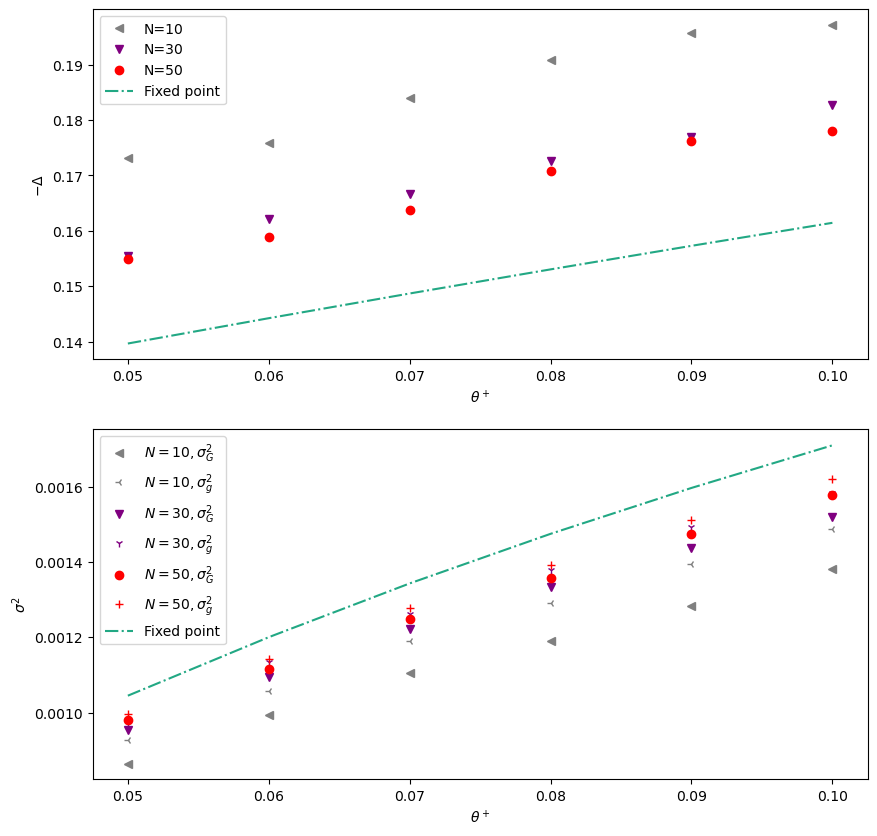

In [43]:
fig,ax = plt.subplots(2,figsize=(10,10))

##### PLOTTING DELTA #####
line1 = ax[0].plot(thetaplus,list_means,"<",label="N="+str(N),color="gray")
line3 = ax[0].plot(thetaplus,list_means3,"v",label="N="+str(N3),color="purple")
line5 = ax[0].plot(thetaplus,list_means5,"o",label="N="+str(N5),color="red")

lineth = ax[0].plot(thetaplus,-list_delta_strong,label="Fixed point",color=listcolors(0.6),ls="-.")

ax[0].set_xlabel(r"$\theta^+$")
ax[0].set_ylabel(r"$-\Delta$")
ax[0].legend()

##### PLOTTING SIGMA #####
transparency=1
ax[1].plot(thetaplus,list_meanvars,marker="<",label=r"$N=$"+str(N)+r"$, \sigma_G^2$",ls="",color="gray",alpha=transparency)
#If we neglect linkage, then we expect Var[z] = 2 L E[alpha**2 X(1-X)] = 2 list_meanvarsX
ax[1].plot(thetaplus,2*list_meanvarsX,marker="3",label=r"$N=$"+str(N)+r"$, \sigma_g^2$",ls="",color="gray",alpha=transparency)
ax[1].plot(thetaplus,list_meanvars3,marker="v",label=r"$N=$"+str(N3)+r"$, \sigma_G^2$",ls="",color="purple",alpha=transparency)
ax[1].plot(thetaplus,2*list_meanvarsX3,marker="1",label=r"$N=$"+str(N3)+r"$, \sigma_g^2$",ls="",color="purple",alpha=transparency)
ax[1].plot(thetaplus,list_meanvars5,marker="o",label=r"$N=$"+str(N5)+r"$, \sigma_G^2$",ls="",color="red",alpha=transparency)
ax[1].plot(thetaplus,2*list_meanvarsX5,marker="+",label=r"$N=$"+str(N5)+r"$, \sigma_g^2$",ls="",color="red",alpha=transparency)

ax[1].plot(thetaplus,sigma2_th_fp, label="Fixed point",color=listcolors(.6),alpha=transparency,ls="-.")
ax[1].set_xlabel(r"$\theta^+$")
ax[1].set_ylabel(r"$\sigma^2$")

ax[1].legend()
plt.savefig("Fig_S4.pdf")

## Breakdown under small mutation rates (Fig. S5)

In [44]:
# Parameters
L=100
N=500

nbpoints=6
list_theta = np.logspace(-np.log10(10*L),0,nbpoints)

eta=1.2
# We know the distribution of the alphas
list_alpha = np.load("alpha100.npy",allow_pickle=True)
list_proba_alpha = np.ones(L)/L
omem2 = L**2/5 #Selection strength = $omega_e^{-2}$ (strong selection)
omega = np.sqrt(2*N/omem2) 

klim = 81 #Degree of precision for the theoretical computations under strong selection
#If klim is too low then the genetic variance sigma2_th_ss will have a bump for strong selection

In [45]:
################################## LOADING ########################################
burn_in = 1/2 #We consider that the system reaches stationarity after a fraction burn_in of the time
########## LOADING N=500 #########
Delta = np.zeros((nbpoints,nbpoints))
nu2 = np.zeros((nbpoints,nbpoints))
genicvar = np.zeros((nbpoints,nbpoints)) #L E[alpha**2 X(1-X)]
vargenicvar = np.zeros((nbpoints,nbpoints)) #variance of the previous item
sigma2 = np.zeros((nbpoints,nbpoints)) #trait variance with linkage
varsigma2 = np.zeros((nbpoints,nbpoints)) #trait variance variance with linkage
rho = np.zeros((nbpoints,nbpoints)) #Autocorrelation parameters

tmp = np.load("breakdown_smallmut/sims_L"+str(L)+"_N"+str(N)+"/0.npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))

list_thetapairs = []
for (k1,thetaplus) in enumerate(list_theta):
    for (k2,thetaminus) in enumerate(list_theta):
        list_thetapairs.append(((k1,k2),(thetaplus,thetaminus)))

for (k,param) in enumerate(list_thetapairs):
    k1,k2=param[0]
    tmp = np.load("breakdown_smallmut/sims_L"+str(L)+"_N"+str(N)+"/"+str(k)+".npy",allow_pickle=True)
    Delta[k1,k2] = np.mean(tmp[3][-postburnin:])-eta
    nu2[k1,k2] = np.var(tmp[3][-postburnin:],ddof=1)
    genicvar[k1,k2] = np.mean(tmp[4][-postburnin:])
    vargenicvar[k1,k2] = np.var(tmp[4][-postburnin:],ddof=1)
    sigma2[k1,k2] = np.mean(tmp[5][-postburnin:])
    varsigma2[k1,k2] = np.var(tmp[5][-postburnin:],ddof=1)
    rho[k1,k2] = -np.log(np.cov(tmp[3][-postburnin-1:-1],tmp[3][-postburnin:])[0,1]/nu2[k1,k2])

In [46]:
#Theoretical predictions
sstarth = np.zeros((nbpoints,nbpoints))
Deltath = np.zeros((nbpoints,nbpoints))
sigma2th = np.zeros((nbpoints,nbpoints))

nu2th = 1/omem2

for (k1,thetaplus) in enumerate(list_theta):
    for (k2,thetaminus) in enumerate(list_theta):
        theta = (thetaplus,thetaminus)
        sstarth[k1,k2] = solve_fp(omem2,theta,eta,L,list_alpha,list_proba_alpha)
        Deltath[k1,k2] = -omega**2 * sstarth[k1,k2]/(2*N)
        sigma2th[k1,k2] = genetic_variance_fp(sstarth[k1,k2],
                                              omem2,
                                              theta,
                                              L,
                                              list_alpha,
                                              list_proba_alpha,
                                              klim=klim)
rho2Nth = omem2 *sigma2th


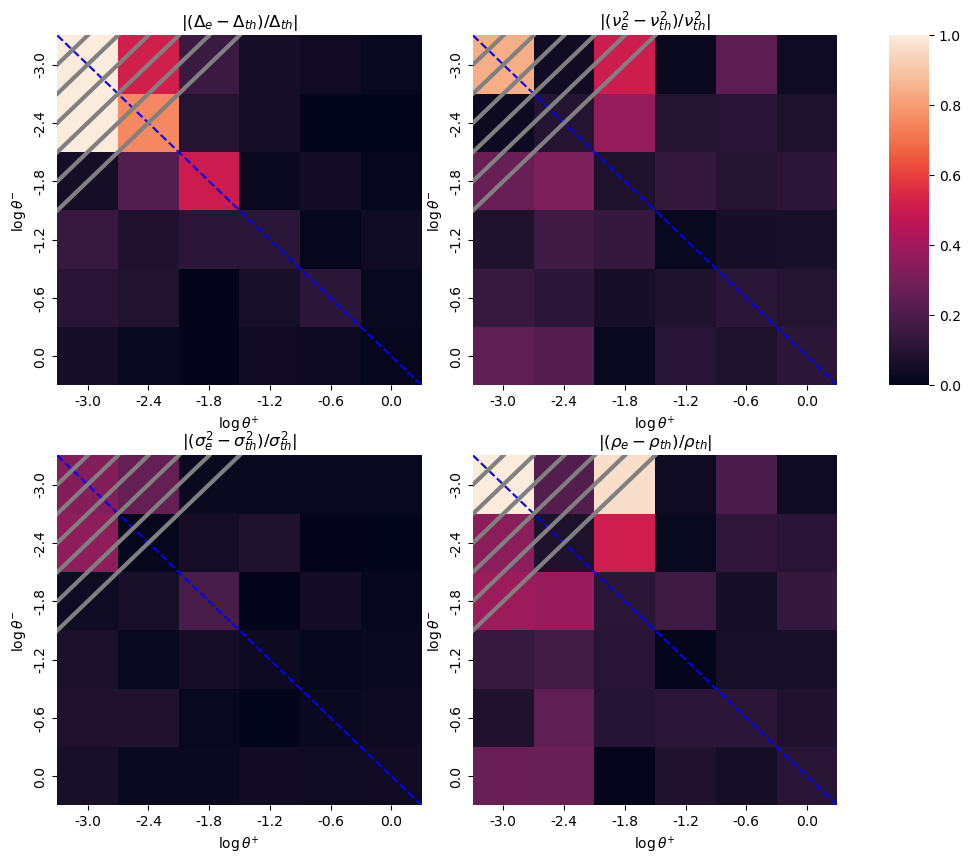

In [47]:
#Heatmaps
str_theta = ["{:2.2}".format(np.log10(theta)) for theta in list_theta]

fig,ax = plt.subplots(2,3,figsize=(10*9/8,10),gridspec_kw={'width_ratios': [3,3,1/3]})

sb.heatmap(np.abs((Delta-Deltath)/Deltath),xticklabels=str_theta,yticklabels=str_theta,vmax=1,vmin=0,cbar=True,ax=ax[0,0],cbar_ax=ax[0,2])
ax[0,0].set_title(r"$|(\Delta_e-\Delta_{th})/\Delta_{th}|$")
ax[0,0].set_xlabel(r"$\log\theta^{+}$")
ax[0,0].set_ylabel(r"$\log\theta^{-}$")
ax[0,0].plot([0,6],[0,6],color="blue",ls="--")
for x in np.linspace(0,3,7):
    ax[0,0].plot([0,x],[x,0],color="grey",lw=3)

sb.heatmap(np.abs((sigma2-sigma2th)/sigma2th),xticklabels=str_theta,yticklabels=str_theta,vmax=1,vmin=0,cbar=False,ax=ax[1,0])
ax[1,0].set_title(r"$|(\sigma^2_e-\sigma^2_{th})/\sigma^2_{th}|$")
ax[1,0].set_xlabel(r"$\log\theta^{+}$")
ax[1,0].set_ylabel(r"$\log\theta^{-}$")
ax[1,0].plot([0,6],[0,6],color="blue",ls="--")
for x in np.linspace(0,3,7):
    ax[1,0].plot([0,x],[x,0],color="grey",lw=3)

sb.heatmap(np.abs((nu2-nu2th)/nu2th),xticklabels=str_theta,yticklabels=str_theta,vmax=1,vmin=0,cbar=False,ax=ax[0,1])
ax[0,1].set_title(r"$|(\nu^2_e-\nu^2_{th})/\nu^2_{th}|$")
ax[0,1].set_xlabel(r"$\log\theta^{+}$")
ax[0,1].set_ylabel(r"$\log\theta^{-}$")
ax[0,1].plot([0,6],[0,6],color="blue",ls="--")
for x in np.linspace(0,3,7):
    ax[0,1].plot([0,x],[x,0],color="grey",lw=3)

sb.heatmap(np.abs((rho*2*N-rho2Nth)/rho2Nth),xticklabels=str_theta,yticklabels=str_theta,mask=(rho<0),vmax=1,vmin=0,cbar=False,ax=ax[1,1])
ax[1,1].set_title(r"$|(\rho_e -\rho_{th})/\rho_{th}|$")
ax[1,1].set_xlabel(r"$\log\theta^{+}$")
ax[1,1].set_ylabel(r"$\log\theta^{-}$")
ax[1,1].plot([0,6],[0,6],color="blue",ls="--")
for x in np.linspace(0,3,7):
    ax[1,1].plot([0,x],[x,0],color="grey",lw=3)

ax[1,2].set_visible(False)

plt.savefig("Fig_S5.pdf")

## Breakdown due to heavy tails of genetic effects (Fig. S6)

In [48]:
# Parameters
L=100
N=500

nbpoints=11
list_param = np.linspace(1,4,nbpoints) #Parameters of the Pareto distribution

theta = (.1,.2)

eta=1.2
omem2 = L**2/5 #Selection strength = $omega_e^{-2}$ (strong selection)
omega = np.sqrt(2*N/omem2)

klim = 81 #Degree of precision for the theoretical computations under strong selection
#If klim is too low then the genetic variance sigma2_th_ss will have a bump for strong selection

In [49]:
################################## LOADING ########################################
burn_in = 1/2 #We consider that the system reaches stationarity after a fraction burn_in of the time
########## LOADING N=500 #########
Delta = np.zeros(nbpoints)
nu2 = np.zeros(nbpoints)
genicvar = np.zeros(nbpoints) #L E[alpha**2 X(1-X)]
vargenicvar = np.zeros(nbpoints) #variance of the previous item
sigma2 = np.zeros(nbpoints) #trait variance with linkage
varsigma2 = np.zeros(nbpoints) #trait variance variance with linkage
rho = np.zeros(nbpoints) #Autocorrelation parameters

list_alpha = np.zeros((nbpoints,L))
list_proba_alpha = np.ones(L)/L

tmp = np.load("pareto/sims_L"+str(L)+"_N"+str(N)+"/0.npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))


for (k,param) in enumerate(list_param):
    tmp = np.load("pareto/sims_L"+str(L)+"_N"+str(N)+"/"+str(k)+".npy",allow_pickle=True)
    Delta[k] = np.mean(tmp[3][-postburnin:]) - eta
    nu2[k] = np.var(tmp[3][-postburnin:],ddof=1)
    genicvar[k] = np.mean(tmp[4][-postburnin:])
    vargenicvar[k] = np.var(tmp[4][-postburnin:],ddof=1)
    sigma2[k] = np.mean(tmp[5][-postburnin:])
    varsigma2[k] = np.var(tmp[5][-postburnin:],ddof=1)
    rho[k] = -np.log(np.cov(tmp[3][-postburnin-1:-1],tmp[3][-postburnin:])[0,1]/nu2[k])*2*N
    list_alpha[k] = tmp[2]

In [50]:
#### Theoretical predictions ####
sstarth = np.zeros(nbpoints)
Deltath = np.zeros(nbpoints)
sigma2th = np.zeros(nbpoints)


for (k,param) in enumerate(list_param):
    sstarth[k] = solve_fp(omem2,theta,eta,L,list_alpha[k],list_proba_alpha)
    sigma2th[k] = genetic_variance_fp(sstarth[k],
                                              omem2,
                                              theta,
                                              L,
                                              list_alpha[k],
                                              list_proba_alpha,
                                              klim=klim)

Deltath = -omega**2 * sstarth/(2*N)
nu2th = 1/omem2 * np.ones(nbpoints)
rhoth = omem2 *sigma2th * np.ones(nbpoints)

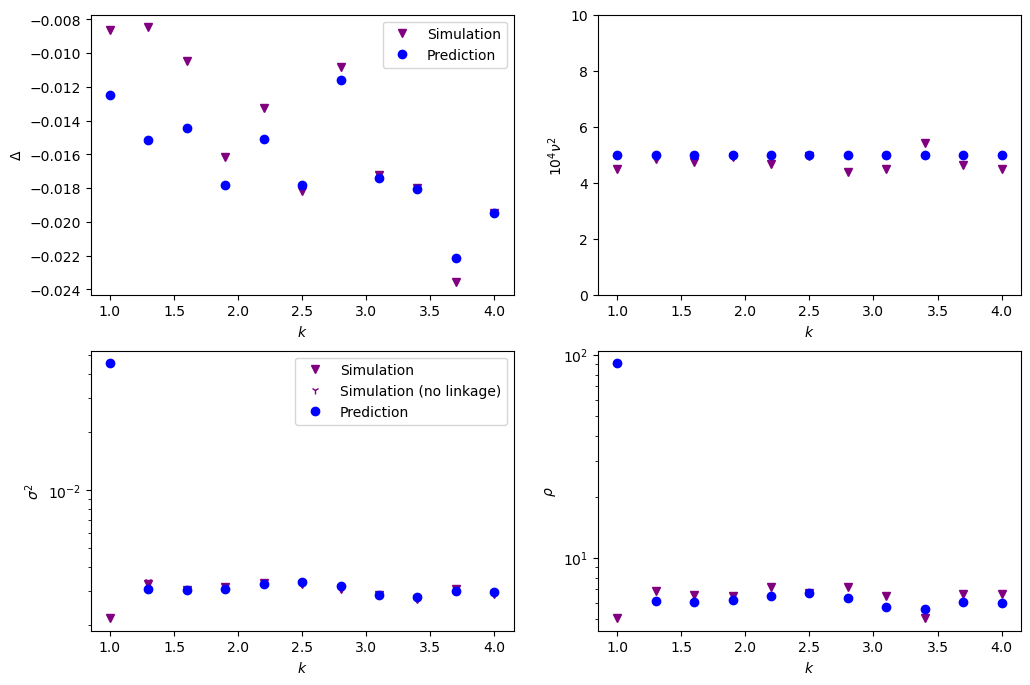

In [51]:
#### Plots ####
fig,ax = plt.subplots(2,2,figsize=(12,8))

ax[0,0].plot(list_param,Delta,"v",color="purple",label="Simulation")
ax[0,0].plot(list_param,Deltath,"o",color="blue",label="Prediction")
ax[0,0].set_xlabel(r"$k$")
ax[0,0].set_ylabel(r"$\Delta$")
ax[0,0].legend()

ax[0,1].plot(list_param,10**4 *nu2,"v",color="purple")
ax[0,1].plot(list_param,10**4 *nu2th,"o",color="blue")
ax[0,1].set_ylim(0,10)
ax[0,1].set_xlabel(r"$k$")
ax[0,1].set_ylabel(r"$10^4\nu^2$")


ax[1,0].plot(list_param,sigma2,"v",color="purple",label="Simulation")
ax[1,0].plot(list_param,2*genicvar,marker="1",ls="",color="purple",label="Simulation (no linkage)")
ax[1,0].plot(list_param,sigma2th,"o",color="blue",label="Prediction")
ax[1,0].set_xlabel(r"$k$")
ax[1,0].set_ylabel(r"$\sigma^2$")
ax[1,0].set_yscale("log")
ax[1,0].legend()

ax[1,1].plot(list_param,rho,"v",color="purple")
ax[1,1].plot(list_param,rhoth,"o",color="blue")
ax[1,1].set_xlabel(r"$k$")
ax[1,1].set_ylabel(r"$\rho$")
ax[1,1].set_yscale("log")
plt.savefig("Fig_S6.pdf")

## Breakdown of the Ornstein-Uhlenbeck process (Fig. S7).

In [52]:
#Parameters
theta= (.1,.2)
eta=1.2
L=100
N=500
list_alpha = np.load("alpha100.npy",allow_pickle=True)
list_proba_alpha = np.ones(L)/L

klim = 81 #Degree of precision for the theoretical computations under strong selection
burn_in = 9/10
#If klim is too low then the genetic variance sigma2_th_fp will have a bump for strong selection

In [53]:
########## LOADING N=500 #########
nbpoints=20

omega = np.zeros(nbpoints)
list_varmeans = np.zeros(nbpoints)
list_rho = np.zeros(nbpoints)
list_rsq = np.zeros(nbpoints) #r2 of log-autocorrelation

tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(0)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))
for k in range(nbpoints):
    tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(k)+".npy",allow_pickle=True)
    omega[k] = tmp[0]
    list_varmeans[k] = np.var(tmp[3][-postburnin:],ddof=1)
    list_rho[k] = -np.log(np.cov(tmp[3][-postburnin-1:-1],tmp[3][-postburnin:])[0,1]/list_varmeans[k])
    limit_autocor = int(np.log(2)/list_rho[k])
    tmprho_u = np.zeros(limit_autocor)
    for j in range(1,limit_autocor):
        autocor = np.cov(tmp[3][-postburnin:-j],tmp[3][-postburnin+j:])[0,1]/list_varmeans[k]
        tmprho_u[j] = -np.log(autocor)
    list_rsq[k] = scp.linregress(np.arange(limit_autocor),tmprho_u)[2]**2
    
tmp = None

omem2 = 2*N/omega**2 #This is the strength of selection omega_e^{-2}

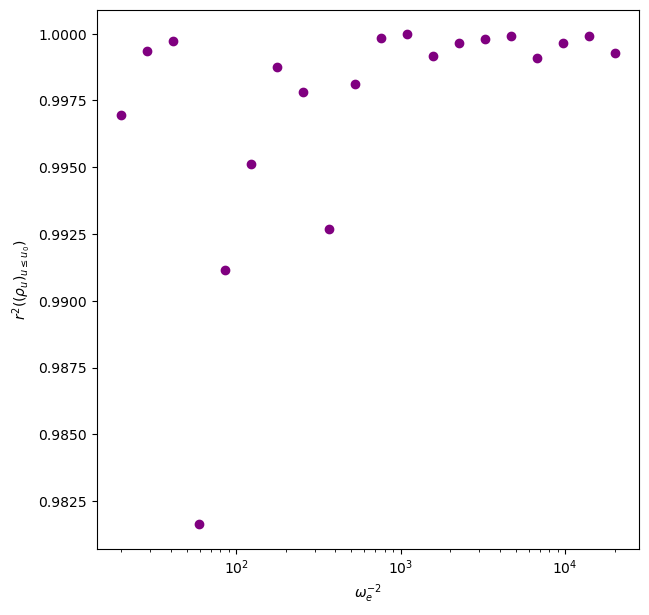

In [54]:
fig,ax = plt.subplots(figsize = (7,7))
ax.plot(omem2,list_rsq,"o",color="purple")
ax.set_xscale("log")
ax.set_xlabel(r"$\omega_e^{-2}$")
ax.set_ylabel(r"$r^2((\rho_u)_{u\leq u_0})$")
plt.savefig("Fig_S7.pdf")

## Correcting for the Bulmer effect
### Theory
We must compute $I'(\delta)$, which is given by
$$
I'(\delta) = -2L\omega_e^{-2}\mathbb{E}\left[\alpha^2\left(\frac{\int p^{2\theta^++1}(1-p)^{2\theta^--1}e^{-2\delta \alpha\omega_e^{-2} p - \alpha^2\omega_e^{-2} p(1-p)} dp}{\int p^{2\theta^+-1}(1-p)^{2\theta^--1}e^{-2\delta \alpha\omega_e^{-2} p - \alpha^2\omega_e^{-2} p(1-p)} dp}-\left(\frac{\int p^{2\theta^+}(1-p)^{2\theta^--1}e^{-2\delta \alpha\omega_e^{-2} p - \alpha^2\omega_e^{-2} p(1-p)} dp}{\int p^{2\theta^+-1}(1-p)^{2\theta^--1}e^{-2\delta \alpha\omega_e^{-2} p - \alpha^2\omega_e^{-2} p(1-p)} dp}\right)^2\right)\right]
$$

In [3]:
def moment_WF(a,b,s,d,theta,klim=81):
    """
    Computes E[X^a(1-X)^b] where X is a WF diffusion with frequency-dependent (FD) selection
    xi(x) = s + d(1-2x)
    and mutation rates given by theta.

    Parameters
    ----------
    a,b: floats, the moments to be computed
    theta: tuple of two positive floats: mutation rates
    s: float: directional selection
    d: float: dominance coefficient
    klim: int: the precision of the approximation (should be odd)
    """
    return np.max([np.min([special.beta(2*theta[0]+a,2*theta[1]+b)/special.beta(2*theta[0],2*theta[1])
         *integral_WF(2*theta[0]+a,2*theta[1]+b,2*s,2*d,klim)
         /integral_WF(2*theta[0],2*theta[1],2*s,2*d,klim),
                         np.ones(np.shape(s))],axis=0),
                 np.zeros(np.shape(s))],axis=0)

def Iprime(delta,omem2,theta,list_alpha,klim):
    """
    Computes I'(delta)
    
    Parameters
    ----------
    delta: distance to the optimum
    
    omem2: strength of selection ($= omega_e^{-2}$)

    theta: mutation rates (tuple of two positive floats)

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)
    
    klim: int: the precision of the approximation (should be odd)
    """
    return -2*L*omem2* np.mean(list_alpha**2 * (
        moment_WF(2,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim)
        -moment_WF(1,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim)**2
    ))
    
def corDelta(delta,omega,L,N,theta,list_alpha,klim):
    """
    The first-order correction to Delta, accounting for LD.
    
    Parameters
    ----------
    delta: distance to the optimum
    
    omega: inverse strength of selection
    
    L: number of loci
    
    N: population size

    theta: mutation rates (tuple of two positive floats)

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)
    
    klim: int: the precision of the approximation (should be odd)
    """
    omem2 = 2*N/omega**2
    bartheta = theta[0]+theta[1]
    eps = (np.log(L)-1+0.58)/(L*omega**2) * bartheta
    #Mean-field quantities to be computed
    Ip = Iprime(delta,omem2,theta,list_alpha,klim)
    mf1 = np.mean((L*list_alpha)**2 
                  *moment_WF(1,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81))
    mf2 = np.mean(L**2 * list_alpha
                  *(theta[0]*moment_WF(0,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
                   -theta[1]*moment_WF(1,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81))
                 )
    
    #Result
    return 4*eps/(1-2*Ip) * L * np.mean(list_alpha *(
        list_alpha**2 * omem2 * mf1 * (
            moment_WF(2,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
              - moment_WF(1,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
                *moment_WF(1,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
        )
        + list_alpha *mf2
        *(
            moment_WF(2,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
              - moment_WF(1,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
                *moment_WF(1,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
        )
    ))/bartheta
    
def corSigma(delta,omega,L,N,theta,list_alpha,klim):
    """
    The first-order correction to Delta, accounting for LD.
    
    Parameters
    ----------
    delta: distance to the optimum
    
    omega: inverse strength of selection
    
    L: number of loci
    
    N: population size

    theta: mutation rates (tuple of two positive floats)

    list_alpha: list of classes of values for gene effect. Typically np.linspace(a,b)
    
    klim: int: the precision of the approximation (should be odd)
    """
    omem2 = 2*N/omega**2
    bartheta = theta[0]+theta[1]
    eps = (np.log(L)-1+0.58)/(L*omega**2) *bartheta
    #Mean-field quantities to be computed
    mf1 = np.mean((L*list_alpha)**2 
                  *moment_WF(1,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81))
    mf2 = np.mean(L**2 * list_alpha
                  *(theta[0]*moment_WF(0,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
                   -theta[1]*moment_WF(1,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81))
                 )
    cD = corDelta(delta,omega,L,N,theta,list_alpha,klim)
    
    #Result
    first_term = 4*cD*omem2 * L * np.mean(list_alpha**3 * (
            moment_WF(2,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
              - moment_WF(1,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
                *moment_WF(1,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
    ))
    second_term =  4*eps * L * np.mean(list_alpha**2 *(
        list_alpha**2 * omem2 * mf1 * (
            moment_WF(2,2,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
              - moment_WF(1,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
                *moment_WF(1,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
        )
        + list_alpha * mf2 
        *(
            moment_WF(2,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
              - moment_WF(1,1,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
                *moment_WF(1,0,-delta*omem2*list_alpha,-omem2*list_alpha**2/2,theta,klim=81)
        )
    ))/bartheta
    return first_term + second_term

### Application

In [4]:
#Parameters
theta= (.1,.2)
eta=1.2
L=100
list_alpha = np.load("alpha100.npy",allow_pickle=True)
list_proba_alpha = np.ones(L)/L

klim = 81 #Degree of precision for the theoretical computations under strong selection
#If klim is too low then the genetic variance sigma2_th_fp will have a bump for strong selection

In [5]:
burn_in = 1/2 #We consider that the system reaches stationarity after a fraction burn_in of the time
########## LOADING N=50 #########
N=50
nbpoints=20

omega = np.zeros(nbpoints)
list_means = np.zeros(nbpoints)
list_meanvarsX = np.zeros(nbpoints) #L E[alpha**2 X(1-X)]
list_meanvars = np.zeros(nbpoints) #trait variance with linkage

tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(0)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))

for k in range(nbpoints):
    tmp = np.load("sims_L"+str(L)+"_N"+str(N)+"/"+str(k)+".npy",allow_pickle=True)
    omega[k] = tmp[0]
    list_means[k] = eta-np.mean(tmp[3][-postburnin:])
    list_meanvarsX[k] = np.mean(tmp[4][-postburnin:])
    list_meanvars[k] = np.mean(tmp[5][-postburnin:])

omem2 = 2*N/omega**2 #Selection strength = $omega_e^{-2}$

########## LOADING N=100 #########
N2=100

list_means2 = np.zeros(nbpoints)
list_meanvarsX2 = np.zeros(nbpoints) #L E[alpha**2 X(1-X)]
list_meanvars2 = np.zeros(nbpoints) #trait variance with linkage
omega2 = np.zeros(nbpoints)

tmp = np.load("sims_L"+str(L)+"_N"+str(N2)+"/"+str(0)+".npy",allow_pickle=True)
postburnin = int(len(tmp[3])*(1-burn_in))

for k in range(nbpoints):
    tmp = np.load("sims_L"+str(L)+"_N"+str(N2)+"/"+str(k)+".npy",allow_pickle=True)
    omega2[k] = tmp[0]
    list_means2[k] = eta-np.mean(tmp[3][-postburnin:])
    list_meanvarsX2[k] = np.mean(tmp[4][-postburnin:])
    list_meanvars2[k] = np.mean(tmp[5][-postburnin:])

In [6]:
#### Predictions ####
###Selection coefficients ###
#Fixed point
sstar_fp = np.array([solve_fp(omem2[k],
                                     theta,
                                     eta,
                                     L,
                                     list_alpha,
                                     list_proba_alpha,
                                     klim=klim)
             for k in range(nbpoints)])

### Observables ###
#Delta
list_delta_strong = -omega**2 * sstar_fp/(2*N)

#Sigma
sigma2_th_fp = np.array([ #fixed_point
                      genetic_variance_fp(sstar_fp[k],
                                              omem2[k],
                                              theta,
                                              L,
                                              list_alpha,
                                              list_proba_alpha,
                                              klim=klim)
                      for k in range(nbpoints)])

###### Correction ######
#N=50
c_Delta = np.array([corDelta(list_delta_strong[k],omega[k],L,N,theta,list_alpha,klim)
                    for k in range(nbpoints)])
c_sigma = np.array([corSigma(list_delta_strong[k],omega[k],L,N,theta,list_alpha,klim)
                    for k in range(nbpoints)])
LD_depletion = (np.log(L)-1+0.58)* sigma2_th_fp/omega**2

#N=500
c_Delta2 = np.array([corDelta(list_delta_strong[k],omega2[k],L,N2,theta,list_alpha,klim)
                    for k in range(nbpoints)])
c_sigma2 = np.array([corSigma(list_delta_strong[k],omega2[k],L,N2,theta,list_alpha,klim)
                    for k in range(nbpoints)])
LD_depletion2 = (np.log(L)-1+0.58)* sigma2_th_fp/omega2**2

/tmp/ipykernel_13101/1239795888.py:36: RuntimeWarning: invalid value encountered in sqrt
  ax[1,0].loglog(omem2,np.sqrt((sigma2_th_fp+c_sigma)*(1-LD_depletion)),


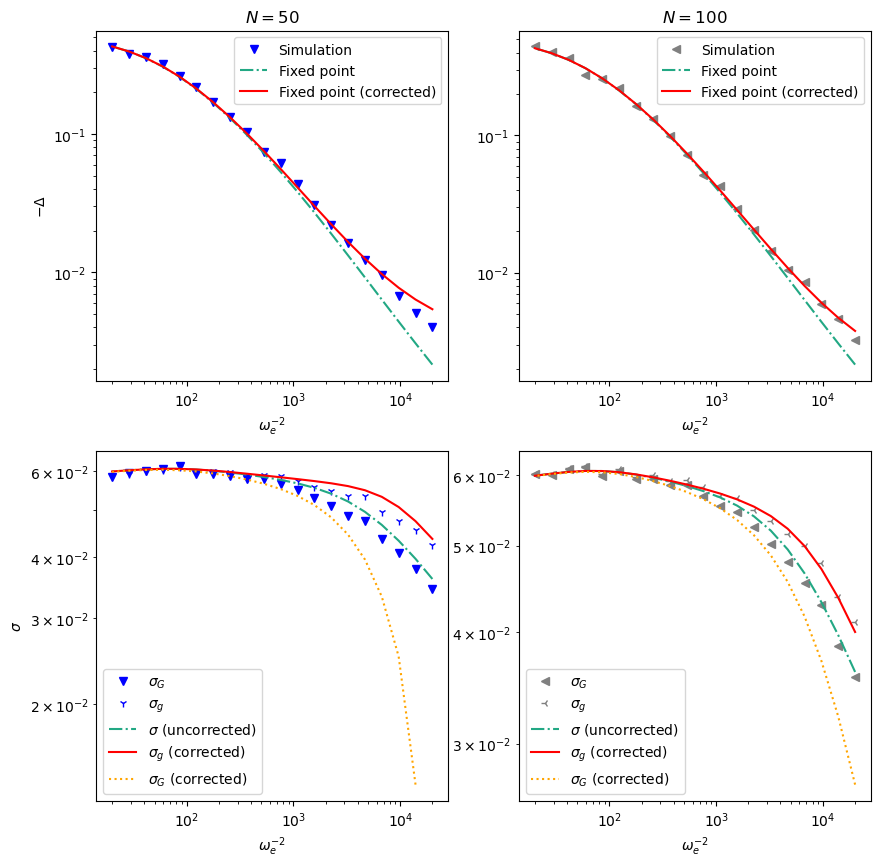

In [9]:
#Plots !
fig,ax = plt.subplots(2,2,figsize=(10,10))
listcolors=plt.get_cmap("viridis")

######### N=50 ###########
##### PLOTTING DELTA #####
ax[0,0].set_xscale("log")
ax[0,0].set_yscale("log")
####Simulations####
line1 = ax[0,0].plot(omem2,list_means,"v",label="Simulation",color="blue")

####Predictions####
line3 = ax[0,0].plot(omem2,-list_delta_strong,label="Fixed point",color=listcolors(0.6),ls="-.")
line4 = ax[0,0].plot(omem2,-list_delta_strong-c_Delta,
                     label="Fixed point (corrected)",color="red",ls="-")
ax[0,0].set_xlabel(r"$\omega_e^{-2}$")
ax[0,0].set_ylabel(r"$-\Delta$")
ax[0,0].legend()
ax[0,0].set_title(r"$N=$"+str(N))

##### PLOTTING SIGMA #####
ax[1,0].set_xscale("log")
ax[1,0].set_yscale("log")
transparency=1

####Simulations####
ax[1,0].plot(omem2,np.sqrt(list_meanvars),marker="v",label=r"$\sigma_G$",ls="",color="blue",alpha=transparency)
#If we neglect linkage, then we expect Var[z] = 2 L E[alpha**2 X(1-X)] = 2 list_meanvarsX
ax[1,0].plot(omem2,np.sqrt(2*list_meanvarsX),marker="1",label=r"$\sigma_g$",ls="",color="blue",alpha=transparency)

####Predictions####
ax[1,0].loglog(omem2,np.sqrt(sigma2_th_fp), label=r"$\sigma$ (uncorrected)",
               color=listcolors(.6),alpha=transparency,ls="-.")
ax[1,0].loglog(omem2,np.sqrt(sigma2_th_fp+c_sigma),
               label=r"$\sigma_g$ (corrected)",color="red",alpha=transparency,ls="-")
ax[1,0].loglog(omem2,np.sqrt((sigma2_th_fp+c_sigma)*(1-LD_depletion)),
               label=r"$\sigma_G$ (corrected)",color="orange",alpha=transparency,ls=":")
ax[1,0].set_xlabel(r"$\omega_e^{-2}$")
ax[1,0].set_ylabel(r"$\sigma$")
ax[1,0].legend()

######### N=100 ###########
##### PLOTTING DELTA #####
ax[0,1].set_xscale("log")
ax[0,1].set_yscale("log")
ax[0,1].set_title(r"$N=$"+str(N2))
####Simulations####
line1 = ax[0,1].plot(omem2,list_means2,"<",label="Simulation",color="grey")

####Predictions####
line3 = ax[0,1].plot(omem2,-list_delta_strong,label="Fixed point",color=listcolors(0.6),ls="-.")
line4 = ax[0,1].plot(omem2,-list_delta_strong-c_Delta2,
                     label="Fixed point (corrected)",color="red",ls="-")
ax[0,1].set_xlabel(r"$\omega_e^{-2}$")
ax[0,1].legend()

##### PLOTTING SIGMA #####
ax[1,1].set_xscale("log")
ax[1,1].set_yscale("log")
transparency=1

####Simulations####
ax[1,1].plot(omem2,np.sqrt(list_meanvars2),marker="<",label=r"$\sigma_G$",ls="",color="grey",alpha=transparency)
#If we neglect linkage, then we expect Var[z] = 2 L E[alpha**2 X(1-X)] = 2 list_meanvarsX
ax[1,1].plot(omem2,np.sqrt(2*list_meanvarsX2),marker="3",label=r"$\sigma_g$",ls="",color="grey",alpha=transparency)

####Predictions####
ax[1,1].loglog(omem2,np.sqrt(sigma2_th_fp), label=r"$\sigma$ (uncorrected)",
               color=listcolors(.6),alpha=transparency,ls="-.")
ax[1,1].loglog(omem2,np.sqrt(sigma2_th_fp+c_sigma2),
               label=r"$\sigma_g$ (corrected)",color="red",alpha=transparency,ls="-")
ax[1,1].loglog(omem2,np.sqrt((sigma2_th_fp+c_sigma2)*(1-LD_depletion2)),
               label=r"$\sigma_G$ (corrected)",color="orange",alpha=transparency,ls=":")
ax[1,1].set_xlabel(r"$\omega_e^{-2}$")
ax[1,1].legend()

plt.savefig("Fig_S8.pdf")